In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cirq
from itertools import combinations
from typing import Iterator, Dict, Tuple, List, Callable, Optional, Sequence, Union

from openfermion import MolecularData, get_sparse_operator, InteractionOperator, get_fermion_operator, QubitOperator
from openfermion.transforms import jordan_wigner, reverse_jordan_wigner
from openfermionpyscf import run_pyscf
from scipy.sparse import csr_matrix
from pyscf import gto, scf, mcscf, ao2mo
from openfermion.chem.molecular_data import spinorb_from_spatial

## FIxing the basis

In [ ]:
# @title
# Subspace utilities

from itertools import combinations
from typing import Dict, Iterator, Sequence, Union
import numpy as np
from scipy.sparse import csr_matrix


def basis_fixed_N(n_sites: int, N: int, dtype=np.uint64) -> np.ndarray:
    """Generate all bitstrings as integers with Hamming weight N on n_sites spin orbitals."""
    if not (0 <= N <= n_sites):
        raise ValueError("N must be in [0, n_sites].")

    dets = []
    for occ in combinations(range(n_sites), N):
        x = 0
        for i in occ:
            x |= (1 << i)
        dets.append(x)

    return np.array(dets, dtype=dtype)


def basis_fixed_N_iter(n_sites: int, N: int) -> Iterator[int]:
    """Memory-light iterator version of basis_fixed_N."""
    if not (0 <= N <= n_sites):
        raise ValueError("N must be in [0, n_sites].")

    for occ in combinations(range(n_sites), N):
        x = 0
        for i in occ:
            x |= (1 << i)
        yield x


def index_map(basis: np.ndarray) -> Dict[int, int]:
    """Map a bitstring integer to its row/column index in the subspace basis."""
    return {int(x): k for k, x in enumerate(basis)}


def basis_alpha_beta(L: int, Na: int, Nb: int) -> np.ndarray:
    """
    Enumerate determinants with separate alpha and beta particle numbers.

    Assumes OpenFermion spin-orbital ordering:
        even indices = alpha spin orbitals
        odd indices  = beta spin orbitals
    """
    if Na > (L + 1) // 2 or Nb > L // 2:
        raise ValueError("More particles than available spin-orbitals.")

    alpha_sites = range(0, L, 2)
    beta_sites = range(1, L, 2)

    dets = []
    for alpha_occ in combinations(alpha_sites, Na):
        for beta_occ in combinations(beta_sites, Nb):
            state = 0

            for i in alpha_occ:
                state |= 1 << i

            for j in beta_occ:
                state |= 1 << j

            dets.append(state)

    dets.sort()
    return np.array(dets, dtype=np.uint64)


def restrict_to_subspace(
    mat_full: Union[np.ndarray, csr_matrix],
    basis: Sequence[int],
) -> np.ndarray:
    """Project a full Hamiltonian matrix into the subspace spanned by integer basis states."""
    basis = np.asarray(basis, dtype=np.int64)

    if hasattr(mat_full, "tocsr"):
        mat_full = mat_full.tocsr()
        return mat_full[basis, :][:, basis].toarray()

    return mat_full[np.ix_(basis, basis)]


def ground_energy_in_subspace(
    H_mat: np.ndarray,
    basis: Sequence[int],
):
    """Return the ground energy and eigenvalues in a chosen determinant subspace."""
    H_sub = restrict_to_subspace(H_mat, basis)
    eigvals = np.linalg.eigvalsh(H_sub)
    return float(eigvals[0]), eigvals


def particle_number_expectation(rho: np.ndarray, n_qubits: int) -> float:
    """Compute <N> for a density matrix in the computational basis."""
    number_diag = np.array(
        [state.bit_count() for state in range(2 ** n_qubits)],
        dtype=float,
    )

    return float(np.real(np.sum(np.diag(rho) * number_diag)))

## The Hamiltonian builder class


This class builds Hamiltonian either by choosing active space <code>CAS(n,m)</code> when <code>use_casscf_orbitals=True</code>

In [ ]:
from dataclasses import dataclass

@dataclass
class HamiltonianData:
    interaction: object
    fermion: object
    qubit: object
    matrix: np.ndarray
    energy: float
    n_system: int
    ancilla: cirq.LineQubit
    system_qubits: list

    # Extra metadata
    geometry: object = None
    input_pauli: object = None


class HamiltonianBuilder:
    def build_molecule(
        self,
        geometry,
        basis="sto-3g",
        multiplicity=1,
        charge=0,
        active_indices=None,
        ancilla_index=0,
        n_active_electrons=None,
        n_active_orbitals=None,
        use_casscf_orbitals=True,
        max_dense_qubits=12,
    ):
        """
        Build a molecular Hamiltonian.

        Modes:

        1. No active space:
            Standard OpenFermion + PySCF Hamiltonian.

        2. Active space but use_casscf_orbitals=False:
            CASCI-like Hamiltonian using Hartree-Fock orbitals.

        3. Active space and use_casscf_orbitals=True:
            True CASSCF active-space Hamiltonian using optimized CASSCF orbitals.

        For large active spaces such as CAS(12,10), this does NOT build a dense matrix.
        """

        use_active_space = (
            n_active_electrons is not None
            and n_active_orbitals is not None
        )

        # ------------------------------------------------------------
        # Case 1: true CASSCF active-space Hamiltonian
        # ------------------------------------------------------------
        if use_active_space and use_casscf_orbitals:

            mol = gto.Mole()
            mol.atom = geometry
            mol.basis = basis
            mol.charge = charge
            mol.spin = multiplicity - 1
            mol.unit = "Angstrom"
            mol.build()

            if multiplicity == 1:
                mf = scf.RHF(mol)
            else:
                mf = scf.ROHF(mol)

            mf.kernel()

            # 1. CAS method that optimizes both orbitals and CI coefficients. Costlier than CASCI. 

            mc = mcscf.CASSCF(
                mf,
                n_active_orbitals,
                n_active_electrons,
            )
            mc.kernel()

            # 2. Active-space one- and two-electron integrals
            
            h1_active, ecore = mc.get_h1eff()
            h2_active = mc.get_h2eff()

            h2_active = ao2mo.restore(
                1,
                h2_active,
                n_active_orbitals,
            )

            # 3. CASSCF gives spatial-orbital integrals. But the fermionic Hamiltonian needs spin orbital

            one_body_spin, two_body_spin = spinorb_from_spatial(
                h1_active,
                h2_active,
            )

            interaction_ham = InteractionOperator(
                ecore,
                one_body_spin,
                0.5 * two_body_spin,
            )

            # active-space fermionic Hamiltonian

            fermion_ham = get_fermion_operator(interaction_ham)

            reference_energy = mc.e_tot

            n_system = 2 * n_active_orbitals

            print("Using true CASSCF active-space Hamiltonian.")
            print("CASSCF energy:", reference_energy)
            print("Active electrons:", n_active_electrons)
            print("Active spatial orbitals:", n_active_orbitals)
            print("Active spin orbitals / qubits:", n_system)

        # ------------------------------------------------------------
        # Case 2: OpenFermion Hamiltonian using HF orbitals
        # ------------------------------------------------------------
        else:

            molecule = MolecularData(
                geometry,
                basis,
                multiplicity,
                charge,
            )

            molecule = run_pyscf(
                molecule,
                run_scf=True,
                run_fci=not use_active_space,
            )

            if use_active_space:

                n_core_orbitals = (
                    molecule.n_electrons - n_active_electrons
                ) // 2

                occupied_indices = list(range(n_core_orbitals))

                if active_indices is None:
                    active_indices = list(
                        range(
                            n_core_orbitals,
                            n_core_orbitals + n_active_orbitals,
                        )
                    )

                interaction_ham = molecule.get_molecular_hamiltonian(
                    occupied_indices=occupied_indices,
                    active_indices=active_indices,
                )

                print("Using CASCI-like active-space Hamiltonian with HF orbitals.")
                print("Frozen occupied orbitals:", occupied_indices)
                print("Active spatial orbitals:", active_indices)

            else:
                interaction_ham = molecule.get_molecular_hamiltonian()

            fermion_ham = get_fermion_operator(interaction_ham)

            reference_energy = getattr(molecule, "fci_energy", None)

            if use_active_space:
                n_system = 2 * len(active_indices)
            else:
                n_system = 2 * molecule.n_orbitals

        # ------------------------------------------------------------
        # Jordan-Wigner transform
        # ------------------------------------------------------------

        qubit_ham = jordan_wigner(fermion_ham)
        qubit_ham.compress()

        H_sparse = get_sparse_operator(
            qubit_ham,
            n_qubits=n_system,
        )

        # ------------------------------------------------------------
        # Dense matrix only for small systems
        # ------------------------------------------------------------


        H_mat = H_sparse.toarray()
        E_corr = np.min(np.linalg.eigvalsh(H_mat))

        ancilla = cirq.LineQubit(ancilla_index)

        system_qubits = [
            cirq.LineQubit(i)
            for i in range(
                ancilla_index + 1,
                ancilla_index + 1 + n_system,
            )
        ]

        return HamiltonianData(
        interaction=interaction_ham,
        fermion=fermion_ham,
        qubit=qubit_ham,
        matrix=H_mat,
        energy=E_corr,
        n_system=n_system,
        ancilla=ancilla,
        system_qubits=system_qubits,
        geometry=geometry,
        input_pauli=None,
    )

In [ ]:
'''from dataclasses import dataclass, field
from typing import Optional, Any

import numpy as np
import cirq

from pyscf import gto, scf, mcscf, ao2mo, mp, cc
try:
    from pyscf import mrpt
except Exception:
    mrpt = None

from openfermion import (
    InteractionOperator,
    get_fermion_operator,
    jordan_wigner,
    get_sparse_operator,
)

# Assumed already available in your notebook/code:
# from openfermion.chem.molecular_data import spinorb_from_spatial
# or wherever your spinorb_from_spatial currently comes from.


@dataclass
class MoleculeHamiltonianResult:
    # Main outputs used by your existing code
    interaction: object
    fermion: object
    qubit: object
    matrix: Optional[np.ndarray]
    energy: Optional[float]
    n_system: int
    ancilla: cirq.LineQubit
    system_qubits: list

    # Extra metadata
    geometry: object = None
    input_pauli: object = None
    metadata: dict = field(default_factory=dict)

    # Energies / benchmarks
    hf_energy: Optional[float] = None
    casscf_energy: Optional[float] = None
    ecore: Optional[float] = None

    exact_ground_energy: Optional[float] = None
    exact_first_excited_energy: Optional[float] = None
    spectral_gap: Optional[float] = None
    eigvals: Optional[np.ndarray] = None

    mp2_energy: Optional[float] = None
    mp2_corr_energy: Optional[float] = None

    ccsd_energy: Optional[float] = None
    ccsd_t_energy: Optional[float] = None
    ccsd_t_corr_energy: Optional[float] = None

    nevpt2_energy: Optional[float] = None
    nevpt2_corr_energy: Optional[float] = None

    # Active-space / orbital diagnostics
    n_active_electrons: Optional[int] = None
    n_active_orbitals: Optional[int] = None
    n_spin_orbitals: Optional[int] = None
    active_indices: Optional[list] = None
    active_indices_base: int = 0
    active_selection_mode: Optional[str] = None

    h1_active: Optional[np.ndarray] = None
    h2_active: Optional[np.ndarray] = None
    one_body_spin: Optional[np.ndarray] = None
    two_body_spin: Optional[np.ndarray] = None

    hf_mo_coeff: Optional[np.ndarray] = None
    hf_mo_energy: Optional[np.ndarray] = None
    hf_mo_occ: Optional[np.ndarray] = None
    casscf_mo_coeff: Optional[np.ndarray] = None
    active_natural_occupations: Optional[np.ndarray] = None

    pyscf_mol: object = None
    pyscf_mf: object = None
    pyscf_mc: object = None

    # Hamiltonian statistics
    n_pauli_terms: Optional[int] = None
    lambda_qubit: Optional[float] = None
    max_abs_coeff: Optional[float] = None
    l2_coeff_norm: Optional[float] = None

    # Sparse matrix, only for small systems if requested
    sparse_matrix: object = None


# Backward-compatible alias, in case some older code uses HamiltonianData
HamiltonianData = MoleculeHamiltonianResult


class HamiltonianBuilder:
    def build_molecule(
        self,
        geometry,
        basis="sto-3g",
        multiplicity=1,
        charge=0,
        active_indices=None,
        ancilla_index=0,
        n_active_electrons=None,
        n_active_orbitals=None,
        use_casscf_orbitals=True,
        max_dense_qubits=12,

        # New optional arguments for reaction-path consistency
        previous_mo=None,
        previous_mol=None,
        active_indices_base=0,

        # Optional benchmark calculations
        run_mp2=False,
        run_ccsd_t=False,
        run_nevpt2=False,

        # Whether to keep PySCF objects in the returned result
        keep_pyscf_objects=True,
    ):
        """
        Build a CASSCF active-space molecular Hamiltonian for one geometry.

        This version is CASSCF-only.

        Input:
            geometry:
                One molecular geometry R_k from the ordered geometry sequence.

            basis:
                Basis set used to construct molecular integrals.

            multiplicity:
                Spin multiplicity. PySCF uses spin = multiplicity - 1.

            charge:
                Molecular charge.

            n_active_electrons:
                Number of active electrons for CAS(nelecas, ncas).

            n_active_orbitals:
                Number of active spatial orbitals.

            active_indices:
                Optional list of active spatial orbital indices for the first
                geometry. Use this to force the initial CAS orbital choice.

            previous_mo, previous_mol:
                Optional CASSCF orbitals and molecule from previous geometry.
                If provided, the previous CASSCF orbitals are projected onto
                the current geometry and used as the CASSCF initial guess.

        Output:
            MoleculeHamiltonianResult containing:
                interaction, fermion, qubit, matrix, energy,
                hf_energy, casscf_energy, exact_ground_energy,
                Pauli statistics, active-space diagnostics, and CASSCF orbitals.

        Notes:
            - This class builds H_sys(R_k) for one geometry R_k.
            - To maintain active-space consistency along a reaction path, call
              this repeatedly and pass result.casscf_mo_coeff and result.pyscf_mol
              into the next geometry as previous_mo and previous_mol.
        """

        # ------------------------------------------------------------
        # Basic validation
        # ------------------------------------------------------------

        use_active_space = (
            n_active_electrons is not None
            and n_active_orbitals is not None
        )

        if not use_active_space:
            raise ValueError(
                "This CASSCF-only builder requires n_active_electrons "
                "and n_active_orbitals."
            )

        if not use_casscf_orbitals:
            raise ValueError(
                "Case 2 has been removed. This builder now only supports "
                "use_casscf_orbitals=True."
            )

        # ------------------------------------------------------------
        # 1. Build PySCF molecule for this geometry R_k
        # ------------------------------------------------------------

        mol = gto.Mole()
        mol.atom = geometry
        mol.basis = basis
        mol.charge = charge
        mol.spin = multiplicity - 1
        mol.unit = "Angstrom"
        mol.build()

        # ------------------------------------------------------------
        # 2. Hartree-Fock reference
        # ------------------------------------------------------------

        if multiplicity == 1:
            mf = scf.RHF(mol)
        else:
            mf = scf.ROHF(mol)

        hf_energy = mf.kernel()

        if not mf.converged:
            print("WARNING: Hartree-Fock did not converge for this geometry.")

        # ------------------------------------------------------------
        # 3. Optional single-reference benchmark energies
        # ------------------------------------------------------------

        mp2_energy = None
        mp2_corr_energy = None
        ccsd_energy = None
        ccsd_t_energy = None
        ccsd_t_corr_energy = None

        if run_mp2:
            try:
                mymp = mp.MP2(mf).set_frozen().run()
                mp2_energy = getattr(mymp, "e_tot", None)
                mp2_corr_energy = getattr(mymp, "e_corr", None)
            except Exception as exc:
                print(f"WARNING: MP2 benchmark failed: {exc}")

        if run_ccsd_t:
            try:
                mycc = cc.CCSD(mf).run()
                ccsd_energy = getattr(mycc, "e_tot", None)
                ccsd_t_corr_energy = mycc.ccsd_t()
                ccsd_t_energy = ccsd_energy + ccsd_t_corr_energy
            except Exception as exc:
                print(f"WARNING: CCSD(T) benchmark failed: {exc}")

        # ------------------------------------------------------------
        # 4. CASSCF setup
        # ------------------------------------------------------------

        mc = mcscf.CASSCF(
            mf,
            n_active_orbitals,
            n_active_electrons,
        )

        mo0 = None
        active_selection_mode = "pyscf_default_frontier_window"

        # Option A: reaction-path orbital continuation
        if previous_mo is not None:
            try:
                mo0 = mcscf.project_init_guess(
                    mc,
                    previous_mo,
                    prev_mol=previous_mol,
                )
                active_selection_mode = "projected_previous_casscf_orbitals"
            except Exception as exc:
                print(f"WARNING: project_init_guess failed: {exc}")
                print("Falling back to active_indices or PySCF default CAS guess.")
                mo0 = None

        # Option B: first-geometry explicit active orbital selection
        if mo0 is None and active_indices is not None:
            try:
                # PySCF's class method is the most convenient form.
                mo0 = mc.sort_mo(
                    active_indices,
                    base=active_indices_base,
                )
            except Exception:
                # Fallback to functional interface.
                mo0 = mcscf.sort_mo(
                    mc,
                    mf.mo_coeff,
                    active_indices,
                    base=active_indices_base,
                )

            active_selection_mode = "explicit_active_indices"

        # Option C: PySCF default active window
        if mo0 is None:
            mc.kernel()
        else:
            mc.kernel(mo0)

        if not mc.converged:
            print("WARNING: CASSCF did not converge for this geometry.")

        casscf_energy = mc.e_tot
        reference_energy = casscf_energy

        # ------------------------------------------------------------
        # 5. Optional multireference perturbative benchmark: NEVPT2
        # ------------------------------------------------------------

        nevpt2_energy = None
        nevpt2_corr_energy = None

        if run_nevpt2:
            if mrpt is None:
                print("WARNING: PySCF mrpt module not available; skipping NEVPT2.")
            else:
                try:
                    nevpt2_corr_energy = mrpt.NEVPT(mc).kernel()
                    nevpt2_energy = casscf_energy + nevpt2_corr_energy
                except Exception as exc:
                    print(f"WARNING: NEVPT2 benchmark failed: {exc}")

        # ------------------------------------------------------------
        # 6. Active-space one- and two-electron integrals
        # ------------------------------------------------------------

        h1_active, ecore = mc.get_h1eff()
        h2_active = mc.get_h2eff()

        h2_active = ao2mo.restore(
            1,
            h2_active,
            n_active_orbitals,
        )

        # ------------------------------------------------------------
        # 7. Spatial-orbital integrals -> spin-orbital integrals
        # ------------------------------------------------------------

        one_body_spin, two_body_spin = spinorb_from_spatial(
            h1_active,
            h2_active,
        )

        interaction_ham = InteractionOperator(
            ecore,
            one_body_spin,
            0.5 * two_body_spin,
        )

        fermion_ham = get_fermion_operator(interaction_ham)

        n_system = 2 * n_active_orbitals

        # ------------------------------------------------------------
        # 8. Jordan-Wigner transform
        # ------------------------------------------------------------

        qubit_ham = jordan_wigner(fermion_ham)
        qubit_ham.compress()

        # ------------------------------------------------------------
        # 9. Hamiltonian statistics for benchmarking/resource plots
        # ------------------------------------------------------------

        coeffs = list(qubit_ham.terms.values())

        n_pauli_terms = len(coeffs)

        if len(coeffs) > 0:
            abs_coeffs = np.array([abs(c) for c in coeffs], dtype=float)
            lambda_qubit = float(np.sum(abs_coeffs))
            max_abs_coeff = float(np.max(abs_coeffs))
            l2_coeff_norm = float(np.sqrt(np.sum(abs_coeffs**2)))
        else:
            lambda_qubit = 0.0
            max_abs_coeff = 0.0
            l2_coeff_norm = 0.0

        # ------------------------------------------------------------
        # 10. Dense matrix and exact diagonalization only if small enough
        # ------------------------------------------------------------

        H_sparse = None
        H_mat = None
        eigvals = None
        exact_ground_energy = None
        exact_first_excited_energy = None
        spectral_gap = None

        if n_system <= max_dense_qubits:
            H_sparse = get_sparse_operator(
                qubit_ham,
                n_qubits=n_system,
            )

            H_mat = H_sparse.toarray()
            eigvals = np.linalg.eigvalsh(H_mat)

            exact_ground_energy = float(eigvals[0])

            if len(eigvals) > 1:
                exact_first_excited_energy = float(eigvals[1])
                spectral_gap = float(eigvals[1] - eigvals[0])

        else:
            print(
                f"Skipping dense matrix: n_system={n_system} > "
                f"max_dense_qubits={max_dense_qubits}."
            )

        # ------------------------------------------------------------
        # 11. Active-space natural occupations
        # ------------------------------------------------------------

        active_natural_occupations = None

        try:
            casdm1 = mc.fcisolver.make_rdm1(
                mc.ci,
                n_active_orbitals,
                n_active_electrons,
            )
            active_natural_occupations = np.sort(
                np.linalg.eigvalsh(casdm1)
            )[::-1]
        except Exception as exc:
            print(f"WARNING: Could not compute active natural occupations: {exc}")

        # ------------------------------------------------------------
        # 12. Cirq qubit bookkeeping
        # ------------------------------------------------------------

        ancilla = cirq.LineQubit(ancilla_index)

        system_qubits = [
            cirq.LineQubit(i)
            for i in range(
                ancilla_index + 1,
                ancilla_index + 1 + n_system,
            )
        ]

        # ------------------------------------------------------------
        # 13. Metadata
        # ------------------------------------------------------------

        metadata = {
            "basis": basis,
            "charge": charge,
            "multiplicity": multiplicity,
            "spin": multiplicity - 1,
            "n_active_electrons": n_active_electrons,
            "n_active_orbitals": n_active_orbitals,
            "n_spin_orbitals": n_system,
            "active_indices": active_indices,
            "active_indices_base": active_indices_base,
            "active_selection_mode": active_selection_mode,
            "use_casscf_orbitals": use_casscf_orbitals,
            "hf_converged": bool(mf.converged),
            "casscf_converged": bool(mc.converged),
            "dense_matrix_built": H_mat is not None,
            "max_dense_qubits": max_dense_qubits,
            "run_mp2": run_mp2,
            "run_ccsd_t": run_ccsd_t,
            "run_nevpt2": run_nevpt2,
        }

        # ------------------------------------------------------------
        # 14. Console summary
        # ------------------------------------------------------------

        print("Using true CASSCF active-space Hamiltonian.")
        print("Active-space selection mode:", active_selection_mode)
        print("HF energy:", hf_energy)
        print("CASSCF energy:", casscf_energy)
        print("Exact active Hamiltonian ground energy:", exact_ground_energy)
        print("Active electrons:", n_active_electrons)
        print("Active spatial orbitals:", n_active_orbitals)
        print("Active spin orbitals / qubits:", n_system)
        print("Number of Pauli terms:", n_pauli_terms)
        print("Qubit lambda = sum |coefficients|:", lambda_qubit)

        # ------------------------------------------------------------
        # 15. Return result
        # ------------------------------------------------------------

        return MoleculeHamiltonianResult(
            # Main outputs
            geometry=geometry,
            interaction=interaction_ham,
            fermion=fermion_ham,
            qubit=qubit_ham,
            matrix=H_mat,
            energy=reference_energy,
            n_system=n_system,
            ancilla=ancilla,
            system_qubits=system_qubits,

            # Metadata
            input_pauli=None,
            metadata=metadata,

            # Energies
            hf_energy=float(hf_energy) if hf_energy is not None else None,
            casscf_energy=float(casscf_energy) if casscf_energy is not None else None,
            ecore=float(ecore) if ecore is not None else None,

            exact_ground_energy=exact_ground_energy,
            exact_first_excited_energy=exact_first_excited_energy,
            spectral_gap=spectral_gap,
            eigvals=eigvals,

            mp2_energy=mp2_energy,
            mp2_corr_energy=mp2_corr_energy,
            ccsd_energy=ccsd_energy,
            ccsd_t_energy=ccsd_t_energy,
            ccsd_t_corr_energy=ccsd_t_corr_energy,
            nevpt2_energy=nevpt2_energy,
            nevpt2_corr_energy=nevpt2_corr_energy,

            # Active-space diagnostics
            n_active_electrons=n_active_electrons,
            n_active_orbitals=n_active_orbitals,
            n_spin_orbitals=n_system,
            active_indices=active_indices,
            active_indices_base=active_indices_base,
            active_selection_mode=active_selection_mode,

            h1_active=h1_active,
            h2_active=h2_active,
            one_body_spin=one_body_spin,
            two_body_spin=two_body_spin,

            hf_mo_coeff=mf.mo_coeff,
            hf_mo_energy=getattr(mf, "mo_energy", None),
            hf_mo_occ=getattr(mf, "mo_occ", None),
            casscf_mo_coeff=mc.mo_coeff,
            active_natural_occupations=active_natural_occupations,

            pyscf_mol=mol if keep_pyscf_objects else None,
            pyscf_mf=mf if keep_pyscf_objects else None,
            pyscf_mc=mc if keep_pyscf_objects else None,

            # Hamiltonian statistics
            n_pauli_terms=n_pauli_terms,
            lambda_qubit=lambda_qubit,
            max_abs_coeff=max_abs_coeff,
            l2_coeff_norm=l2_coeff_norm,
            sparse_matrix=H_sparse,
        )'''

In [ ]:
builder = HamiltonianBuilder()

mol = builder.build_molecule(
    geometry = [('H', (-0.04, 0.0, -0.3674)), ('H', (0.0, 0.0, 0.3674))],
    basis="sto-3g",
    multiplicity=1,
    charge=0,
    active_indices=None,
    ancilla_index=0,
    n_active_electrons=None,
    n_active_orbitals=None,
    use_casscf_orbitals=True,
)

interaction_ham, fermion_ham, qubit_ham, H_mat, E_corr, n_system, ancilla, system_qubits = (
    mol.interaction, mol.fermion, mol.qubit, mol.matrix, mol.energy,
    mol.n_system, mol.ancilla, mol.system_qubits
)

### Pauli Hamiltonian

In [5]:
'''pauli = builder.build_pauli(
    pauli_qubit=QubitOperator("Z0 Z1", 1.0),
    n_qubits=2,
)
pauli_fermion, pauli_qubit, pauli_mat, pauli_energy, pauli_n_system, pauli_ancilla, pauli_system_qubits = (
    pauli.fermion, pauli.qubit, pauli.matrix, pauli.energy,
    pauli.n_system, pauli.ancilla, pauli.system_qubits)'''

'pauli = builder.build_pauli(\n    pauli_qubit=QubitOperator("Z0 Z1", 1.0),\n    n_qubits=2,\n)\npauli_fermion, pauli_qubit, pauli_mat, pauli_energy, pauli_n_system, pauli_ancilla, pauli_system_qubits = (\n    pauli.fermion, pauli.qubit, pauli.matrix, pauli.energy,\n    pauli.n_system, pauli.ancilla, pauli.system_qubits)'

## Square-wave filter class

### Number of modes (reps of A = 2*number_of_modes+1): 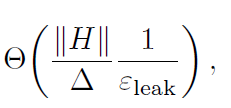 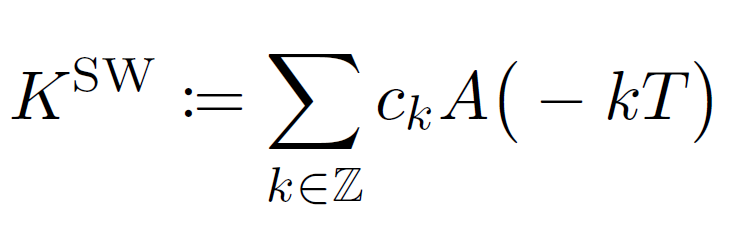

Returns normalized <code>cvals</code>

        c_0 = A/2,

        c_k = sign * i A / (pi k), for odd nonzero k,
        
        c_k = 0, for even nonzero k.

In [6]:
class SquareWaveFilter:
    """
    Periodic square-wave cooling filter used for the dissipative W(sqrt(tau)) block.

    The frequency-domain square wave is expanded as

        fhat(omega) = sum_k c_k exp(i k T omega),

    with

        T = pi / L.

    The corresponding filtered jump operator is

        K_Nomega = sum_k c_k A(-kT),

    where

        A(-kT) = exp(i H kT) A exp(-i H kT).

    The coefficients c_k determine the FSim/iSWAP kick angles via

        theta_k = sqrt(tau) * |c_k| / 2,

    and the ancilla phase via

        phi_k = arg(c_k).

    For the square-wave convention used here:
        c_0 = A/2,
        c_k = sign * i A / (pi k), for odd nonzero k,
        c_k = 0, for even nonzero k.
    """

    def __init__(self):
        self.data = None

    def get_coefficients(
        self,
        L,
        K,
        tau,
        A=1.0,
        window=None,
        p=1,
        drop_zeros=True,
        eps=1e-15,
        sign=+1,
    ):
        """
        Returns the coefficient data needed by the rest of the code.

        Important output names:
            omega_filter : historical name from your code.
                           Here omega_filter = k*T = k*pi/L.
                           It is really the time displacement t_k.

            cvals        : Fourier coefficients c_k.

            ks_filter    : Fourier mode labels k.

            filter_terms : list(zip(ks_filter, cvals)).
                           This is the main object used by build_W_circuit
                           and build_W_matrix.

            theta_filter : theta_k = sqrt(tau) * |c_k| / 2.
                           These are the FSim/iSWAP angles.

            phi_filter   : phi_k = 0 for k=0, otherwise arg(c_k).
                           These set the ancilla Rz phases.

            T_filter     : T = pi/L.
        """

        ks = np.arange(-K, K + 1, dtype=int)
        T_filter = np.pi / L

        # Historical variable name.
        # Conceptually this is t_k = k*T_filter.
        omega = ks * T_filter

        cvals = np.zeros_like(omega, dtype=complex)

        # k = 0 mode
        cvals[ks == 0] = 0.5 * A

        # odd nonzero modes
        odd_nonzero = (ks != 0) & (ks % 2 != 0)
        cvals[odd_nonzero] = sign * 1j * A / (np.pi * ks[odd_nonzero])

        # optional windowing
        if window:
            Kmax = (len(ks) - 1) // 2

            if window.lower().startswith("lanczos"):
                w = np.sinc(ks / (Kmax + 1)) ** p

            elif window.lower().startswith("fejer"):
                w = 1.0 - np.abs(ks) / (Kmax + 1)
                w[w < 0] = 0.0

            else:
                w = np.ones_like(ks, dtype=float)

            cvals = w * cvals

            # keep c0 exact after windowing
            cvals[ks == 0] = 0.5 * A

        if drop_zeros:
            keep = np.abs(cvals) > eps
            ks = ks[keep]
            omega = omega[keep]
            cvals = cvals[keep]

        theta_filter = np.sqrt(tau) * np.abs(cvals) / 2.0

        phi_filter = np.array(
            [
                0.0 if k == 0 else np.angle(c)
                for k, c in zip(ks, cvals)
            ],
            dtype=float,
        )

        filter_terms = list(zip(ks, cvals))
        filter_gate_params = list(zip(ks, cvals, theta_filter, phi_filter))

        self.data = {
            "L": L,
            "K": K,
            "tau": tau,
            "A": A,
            "sign": sign,
            "T_filter": T_filter,

            # names compatible with your current code
            "omega_filter": omega,
            "cvals": cvals,
            "ks_filter": ks,
            "filter_terms": filter_terms,

            # useful gate quantities
            "theta_filter": theta_filter,
            "phi_filter": phi_filter,
            "filter_gate_params": filter_gate_params,
        }

        return self.data

    def plot(self, coeffs=None, num_points=2000):
        """
        Plot:
            1. reconstructed periodic square-wave filter fhat(omega)
            2. comb-like time-domain coefficient plot at t_k = kT

        If coeffs is None, this uses the most recent output of get_coefficients().
        """

        if coeffs is None:
            if self.data is None:
                raise ValueError("Run get_coefficients(...) before plot(...).")
            coeffs = self.data

        L = coeffs["L"]
        T_filter = coeffs["T_filter"]
        ks_filter = coeffs["ks_filter"]
        cvals = coeffs["cvals"]
        sign = coeffs["sign"]

        # ------------------------------------------------------------
        # 1. Reconstruct the frequency-domain square wave
        # ------------------------------------------------------------
        omega_grid = np.linspace(-L, L, num_points)

        fhat = np.zeros_like(omega_grid, dtype=complex)

        for k, ck in zip(ks_filter, cvals):
            fhat += ck * np.exp(1j * k * T_filter * omega_grid)

        ideal = np.zeros_like(omega_grid, dtype=float)

        if sign == +1:
            # convention: fhat(omega) = 1 for omega < 0, 0 for omega > 0
            ideal[omega_grid < 0] = 1.0
            ideal[omega_grid > 0] = 0.0
            ideal[omega_grid == 0] = 0.5
        else:
            # flipped convention
            ideal[omega_grid > 0] = 1.0
            ideal[omega_grid < 0] = 0.0
            ideal[omega_grid == 0] = 0.5

        plt.figure(figsize=(7, 4))
        plt.plot(omega_grid, np.real(fhat), label="Reconstructed Re[fhat(omega)]")
        plt.plot(omega_grid, ideal, "--", label="Ideal square wave")
        plt.xlabel("Bohr frequency omega")
        plt.ylabel("fhat(omega)")
        plt.title("Periodic square-wave filter reconstructed from c_k")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

        # ------------------------------------------------------------
        # 2. Comb-like time-domain coefficient plot
        # ------------------------------------------------------------
        t_filter = ks_filter * T_filter

        plt.figure(figsize=(7, 4))
        plt.stem(t_filter, np.abs(cvals))
        plt.xlabel("time displacement t_k = kT")
        plt.ylabel("|c_k|")
        plt.title("Comb-like time-domain coefficients")
        plt.grid(True, alpha=0.3)
        plt.show()

        # Optional: real/imaginary coefficient plot
        plt.figure(figsize=(7, 4))
        plt.stem(t_filter, np.real(cvals), linefmt="C0-", markerfmt="C0o", basefmt=" ")
        plt.stem(t_filter, np.imag(cvals), linefmt="C1-", markerfmt="C1s", basefmt=" ")
        plt.xlabel("time displacement t_k = kT")
        plt.ylabel("coefficient value")
        plt.title("Real and imaginary parts of c_k")
        plt.grid(True, alpha=0.3)
        plt.legend(["Re(c_k)", "Im(c_k)"])
        plt.show()

## Utils

In [7]:
def pauli_sum_matrix(pauli_sum, qubits):
    """
    Convert a Cirq PauliSum into an explicit matrix using the given qubit order.

    Important:
        The matrix basis ordering is determined by the order in `qubits`.
    """
    PAULI_DICT = {
        'I': np.eye(2, dtype=complex),
        'X': np.array([[0, 1], [1, 0]], dtype=complex),
        'Y': np.array([[0, -1j], [1j, 0]], dtype=complex),
        'Z': np.array([[1, 0], [0, -1]], dtype=complex),
    }

    dim = 2 ** len(qubits)
    mat = np.zeros((dim, dim), dtype=complex)

    for term in pauli_sum:
        m = np.eye(1, dtype=complex)

        for q in qubits:
            p = str(term[q]) if q in term else 'I'
            m = np.kron(m, PAULI_DICT[p])

        mat += complex(term.coefficient) * m

    return mat


def fast_qubit_op_to_paulisum(qubit_op, system_qubits):
    """
    Convert an OpenFermion QubitOperator into a Cirq PauliSum.

    This keeps the same qubit indexing:
        OpenFermion index idx -> system_qubits[idx]
    """
    pauli_sum = cirq.PauliSum()

    for term, coefficient in qubit_op.terms.items():
        coeff = complex(coefficient)

        # Most chemistry Hamiltonian coefficients should be real.
        # If numerically real, cast to float for Cirq compatibility.
        if abs(coeff.imag) < 1e-12:
            coeff = float(coeff.real)

        if not term:
            pauli_sum += coeff * cirq.PauliString()
            continue

        cirq_term = cirq.PauliString({
            system_qubits[idx]: getattr(cirq, op)
            for idx, op in term
        })

        pauli_sum += coeff * cirq_term

    return pauli_sum


def hf_density_from_occupations(n_system_qubits, occ_spin_orbs):
    """
    Build a computational-basis density matrix from occupied spin-orbitals.

    Convention verified for your notebook:
        spin-orbital index i maps to computational basis bit 2^i.

    Therefore:
        occ_spin_orbs = [0, 1]
        gives integer bitstring 3, i.e. binary ...0011.

    Do not flip this unless you also change the rest of the qubit-ordering
    convention in the notebook.
    """
    dim = 2 ** n_system_qubits
    ket = np.zeros((dim, 1), dtype=complex)

    bitstring = 0
    for i in occ_spin_orbs:
        bitstring |= (1 << i)

    ket[bitstring, 0] = 1.0

    return ket @ ket.conj().T


def partial_trace_first_qubit(rho_tot, n_system_qubits):
    """
    Trace out the first qubit, assumed to be the ancilla.

    Input ordering:
        rho_tot acts on ancilla ⊗ system.

    Output:
        reduced density matrix on the system register.
    """
    d_sys = 2 ** n_system_qubits

    rho_tot = np.asarray(rho_tot, dtype=complex)

    # Reshape as:
    #   ancilla_ket, system_ket, ancilla_bra, system_bra
    rho4 = rho_tot.reshape(2, d_sys, 2, d_sys)

    # Trace over ancilla index.
    return np.einsum('abac->bc', rho4)

## $A\left(\sqrt{\tau_s}\right)$ circuit

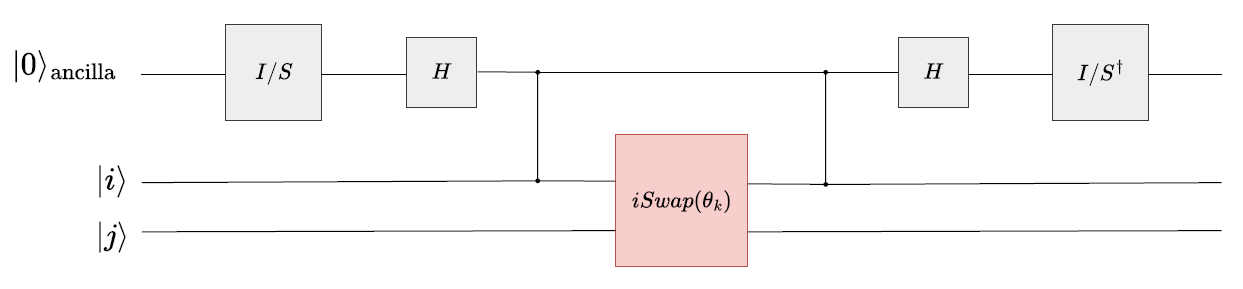

![So](image-1.png)

In [8]:
def A_ckt(theta=None, phi=None, k=None, ck=None, tau_s=None, jump_type="Ax"):
    """
    Build the local A_k(sqrt(tau)) kick circuit.

    Can be used in two ways:

    1. Direct gate-parameter mode:
        A_ckt(theta=theta_k, phi=phi_k, jump_type="Ax")

    2. Filter-coefficient mode:
        A_ckt(k=k, ck=ck, tau_s=tau_s, jump_type="Ax")

       In this mode:
            theta_k = sqrt(tau_s) * |ck| / 2
            phi_k   = 0 if k == 0 else arg(ck)

    jump_type:
        "Ax" implements A_x = (X_i X_j + Y_i Y_j)/2

        "Ay" implements A_y = (Y_i X_j - X_i Y_j)/2
        by inserting Rz(pi/2) on qb before iSWAP and Rz(-pi/2)
        on qb after iSWAP.
    """

    anc = cirq.LineQubit(0)
    qa  = cirq.LineQubit(1)
    qb  = cirq.LineQubit(2)

    # ------------------------------------------------------------
    # Get theta, phi from filter coefficient if ck is provided
    # ------------------------------------------------------------
    if ck is not None:
        if tau_s is None:
            raise ValueError("If ck is provided, tau_s must also be provided.")

        theta = np.sqrt(tau_s) * abs(ck) / 2.0
        phi = 0.0 if k == 0 else np.angle(ck)

    # ------------------------------------------------------------
    # Backward-compatible defaults
    # ------------------------------------------------------------
    if theta is None:
        theta = np.pi / 4

    if phi is None:
        phi = 0.0

    jump_type = jump_type.lower()

    if jump_type not in ["ax", "ay"]:
        raise ValueError("jump_type must be either 'Ax' or 'Ay'.")

    c = cirq.Circuit()

    # Rz(phi) H CZ
    c.append(cirq.rz(phi)(anc))
    c.append(cirq.H(anc))
    c.append(cirq.CZ(anc, qa))

    # For Ay, conjugate the iSWAP block by local Rz rotations on qb.
    # This realizes the paper's Ay version while keeping the rest unchanged.
    if jump_type == "ay":
        c.append(cirq.rz(np.pi / 2)(qb))

    # ordinary FSim/iSWAP on system qubits, not controlled by ancilla
    c.append(cirq.FSimGate(theta=theta, phi=0.0)(qa, qb))

    if jump_type == "ay":
        c.append(cirq.rz(-np.pi / 2)(qb))

    # CZ H Rz(-phi)
    c.append(cirq.CZ(anc, qa))
    c.append(cirq.H(anc))
    c.append(cirq.rz(-phi)(anc))

    return c, (anc, qa, qb)



# ============================================================
# JW-string-aware implementation of the local kick on a pair
# ============================================================
#
# A_ckt above is only the three-qubit, no-JW-string template.
# The real pair insertion must know the actual orbital indices i,j,
# because for non-neighbouring JW modes the bare jump is
#
#   Ax_ij = 1/2 (X_i Z_{i+1}...Z_{j-1} X_j
#              + Y_i Z_{i+1}...Z_{j-1} Y_j)
#
# and
#
#   Ay_ij = 1/2 (Y_i Z_{i+1}...Z_{j-1} X_j
#              - X_i Z_{i+1}...Z_{j-1} Y_j).
#
# So the string belongs in A_on_pair, not in A_ckt.


def _jw_string_system_qubits(system_qubits, i, j):
    """Return system qubits strictly between fermionic modes i and j."""
    lo, hi = sorted((i, j))
    return [system_qubits[m] for m in range(lo + 1, hi)]


def _pauli_string_rotation(pauli_ops, angle):
    """
    Return a Cirq operation implementing exp(-i * angle * P),
    where P is the product of the Pauli operations in pauli_ops.

    Cirq's PauliString power convention gives this up to a global phase,
    which is irrelevant for the induced channel here.
    """
    ps = cirq.PauliString()
    for op in pauli_ops:
        ps *= op
    return ps ** (2.0 * angle / np.pi)


def _append_jw_string_hopping_evolution(circuit, system_qubits, i, j, theta, jump_type="Ax"):
    """
    Append exp(-i theta A_ij) for the JW-mapped bilinear jump.

    For jump_type="Ax":
        A_ij = 1/2 (X_i S_ij X_j + Y_i S_ij Y_j)

    For jump_type="Ay":
        A_ij = 1/2 (Y_i S_ij X_j - X_i S_ij Y_j)

    where S_ij = product of Z's on modes strictly between i and j.

    This replaces the old bare FSim/iSWAP block.  When i and j are
    neighbouring modes, S_ij is empty and this reduces to the usual
    iSWAP-type evolution, up to a global phase.
    """
    jump_type = jump_type.lower()
    if jump_type not in ["ax", "ay"]:
        raise ValueError("jump_type must be either 'Ax' or 'Ay'.")

    qi = system_qubits[i]
    qj = system_qubits[j]
    z_ops = [cirq.Z(q) for q in _jw_string_system_qubits(system_qubits, i, j)]

    if jump_type == "ax":
        # exp[-i theta/2 X_i S X_j] exp[-i theta/2 Y_i S Y_j]
        # The two Pauli strings commute.
        circuit.append(_pauli_string_rotation([cirq.X(qi), *z_ops, cirq.X(qj)], +theta / 2.0))
        circuit.append(_pauli_string_rotation([cirq.Y(qi), *z_ops, cirq.Y(qj)], +theta / 2.0))

    else:  # "ay"
        # exp[-i theta/2 Y_i S X_j] exp[+i theta/2 X_i S Y_j]
        # because Ay = 1/2(Y_i S X_j - X_i S Y_j).
        circuit.append(_pauli_string_rotation([cirq.Y(qi), *z_ops, cirq.X(qj)], +theta / 2.0))
        circuit.append(_pauli_string_rotation([cirq.X(qi), *z_ops, cirq.Y(qj)], -theta / 2.0))


def A_on_pair(ancilla, system_qubits, i, j, theta, phi, jump_type="Ax"):
    """
    Insert the Appendix-H local kick on the actual system pair (i,j).

    This is the string-aware version.  It implements

        Rz(phi) H CZ(a,i) exp[-i theta A_ij] CZ(a,i) H Rz(-phi),

    where A_ij includes the JW parity string Z_{min(i,j)+1}...Z_{max(i,j)-1}.
    """
    jump_type = jump_type.lower()
    if jump_type not in ["ax", "ay"]:
        raise ValueError("jump_type must be either 'Ax' or 'Ay'.")

    if i == j:
        raise ValueError("A_on_pair requires two distinct system modes i != j.")

    c = cirq.Circuit()

    # Rz(phi) H CZ(a,i)
    c.append(cirq.rz(phi)(ancilla))
    c.append(cirq.H(ancilla))
    c.append(cirq.CZ(ancilla, system_qubits[i]))

    # String-aware replacement for the old FSim/iSWAP block.
    _append_jw_string_hopping_evolution(
        c,
        system_qubits=system_qubits,
        i=i,
        j=j,
        theta=theta,
        jump_type=jump_type,
    )

    # CZ(a,i) H Rz(-phi)
    c.append(cirq.CZ(ancilla, system_qubits[i]))
    c.append(cirq.H(ancilla))
    c.append(cirq.rz(-phi)(ancilla))

    return c


## $W\left(\sqrt{\tau_s}\right)$ circuit

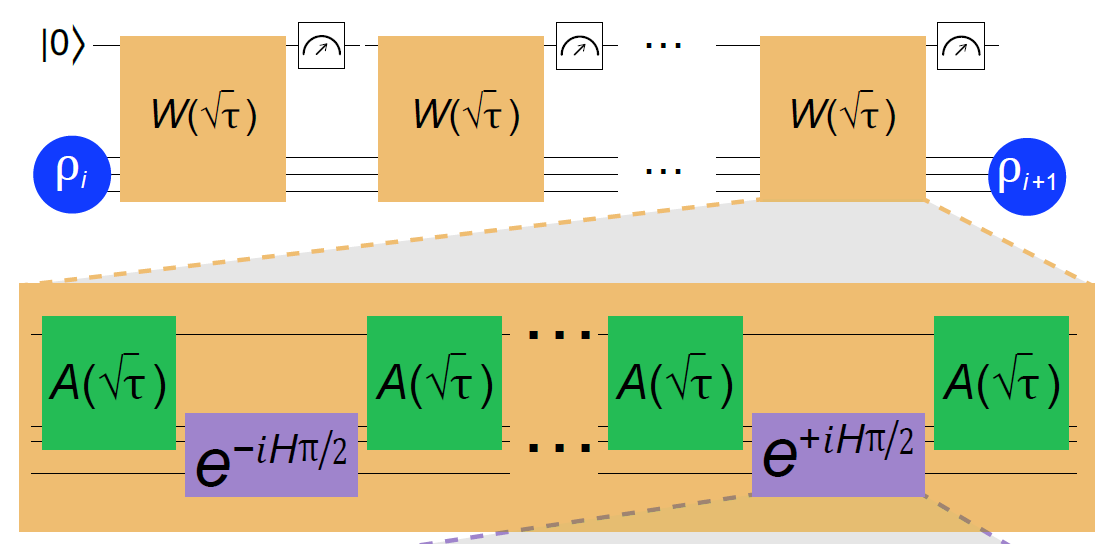

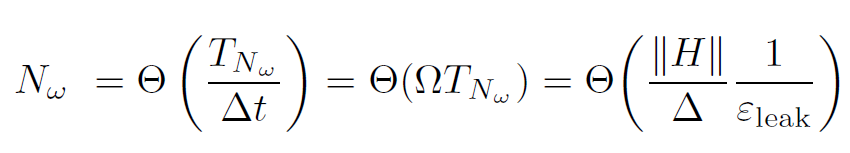

In [ ]:
from openfermion.circuits import trotter

def build_U_H_trotter(system_qubits, H_int, time_s, trotter_steps_H=1):
    """
    Build a Trotter circuit for exp(-i H time_s).

    Important:
        positive time_s  -> exp(-i H time_s)
        negative time_s  -> exp(+i H |time_s|)

    Therefore, to implement exp(+i H T_filter), call:

        build_U_H_trotter(..., time_s=-T_filter)
    """
    custom_algorithm = trotter.LowRankTrotterAlgorithm(final_rank=2)
    dt = time_s / trotter_steps_H

    circ = cirq.Circuit()

    for _ in range(trotter_steps_H):
        circ += cirq.Circuit(
            trotter.simulate_trotter(
                system_qubits,
                H_int,
                time=dt,
                omit_final_swaps=True,
                algorithm=custom_algorithm,
            ),
            strategy=cirq.InsertStrategy.EARLIEST,
        )

    return circ


def build_W_circuit(
    ancilla, system_qubits, H_int, tau_s,
    filter_terms,
    pairs, weights,
    reps=None,
    trotter_steps_H=1,
    seed=None,
    T_filter=None,
):
    """
    Build W(sqrt(tau)) using complex square-wave filter coefficients.

    tau_s:
        Dissipative timestep tau.
        This controls the local kick angle:

            theta_k = sqrt(tau_s) * |c_k| / 2.

    T_filter:
        Hamiltonian evolution spacing T in the square-wave filter:

            A(-kT) = exp(+i H kT) A exp(-i H kT).

        The paper's W circuit uses exp(+i H T) in the forward half
        and exp(-i H T) in the backward half.

        If T_filter is None, this function falls back to tau_s only for
        backward compatibility, but for the paper implementation you
        should pass T_filter explicitly.

    filter_terms:
        list of (k, ck), where k is Fourier mode and ck is complex coefficient.

    pairs:
        Either old format:
            [(i, j), ...]

        or new combined jump format:
            [(i, j, "Ax"), (i, j, "Ay"), ...]

        If the old format is used, jump_type defaults to "Ax".

    reps:
        Optional. If provided, only use modes with |k| <= reps.
    """

    if T_filter is None:
        T_filter = tau_s
        print(
            "Warning: T_filter was not provided. "
            "Using T_filter=tau_s for backward compatibility. "
            "For the paper circuit, pass T_filter explicitly."
        )

    rng = np.random.default_rng(seed)

    w = np.array(weights, dtype=float)
    w = w / w.sum()

    # Optional truncation by reps.
    if reps is not None:
        active_terms = [(k, ck) for (k, ck) in filter_terms if abs(k) <= reps]
    else:
        active_terms = list(filter_terms)

    U_H_plus = build_U_H_trotter(
        system_qubits,
        H_int,
        time_s=-T_filter,
        trotter_steps_H=trotter_steps_H,
    )

    U_H_minus = cirq.Circuit(cirq.inverse(U_H_plus))

    circ = cirq.Circuit()

    def append_U_H_plus():
        for op in U_H_plus.all_operations():
            circ.append(op)

    def append_U_H_minus():
        for op in U_H_minus.all_operations():
            circ.append(op)

    # ------------------------------------------------------------
    # Sample one jump operator for the whole W block.
    #
    # Supports:
    #     old pair format: (i, j)
    #     new pair format: (i, j, jump_type)
    # ------------------------------------------------------------
    chosen_pair = pairs[rng.choice(len(pairs), p=w)]
    #print(f"Chosen pair for this W block: {chosen_pair}")

    if len(chosen_pair) == 2:
        i, j = chosen_pair
        jump_type = "Ax"
    elif len(chosen_pair) == 3:
        i, j, jump_type = chosen_pair
    else:
        raise ValueError(
            "Each entry of pairs must be either (i, j) or (i, j, jump_type)."
        )

    # ------------------------------------------------------------
    # Forward half:
    #
    #     product over k: A_k(sqrt(tau)) exp(+i H T)
    # ------------------------------------------------------------
    for k, ck in active_terms:
        theta_k = np.sqrt(tau_s) * abs(ck) / 2.0
        phi_k = 0.0 if k == 0 else np.angle(ck)

        circ += A_on_pair(
            ancilla,
            system_qubits,
            i,
            j,
            theta_k,
            phi_k,
            jump_type=jump_type,
        )

        append_U_H_plus()

    # ------------------------------------------------------------
    # Backward half:
    #
    #     reverse product over k: exp(-i H T) A_k(sqrt(tau))
    # ------------------------------------------------------------
    for k, ck in reversed(active_terms):
        theta_k = np.sqrt(tau_s) * abs(ck) / 2.0
        phi_k = 0.0 if k == 0 else np.angle(ck)

        append_U_H_minus()

        circ += A_on_pair(
            ancilla,
            system_qubits,
            i,
            j,
            theta_k,
            phi_k,
            jump_type=jump_type,
        )

    return circ

In [ ]:
def run_W_chain_circuit(
    system_qubits,
    H_int,
    anc,
    tau,
    filter_terms,
    pairs,
    weights,
    N_applications,
    reps_per_W=None,
    occ_spin_orbs=None,
    trotter_steps_H=1,
    rng_seed=123,
    T_filter=None,
    H_mat_sys=None,
    initial_rho_sys=None,
):
    """
    Run repeated applications of the dissipative W(sqrt(tau)) channel.

    Channel:
        rho_sys -> Tr_anc[
            W ( |0><0|_anc ⊗ rho_sys ) W†
        ]

    Important:
        H_mat_sys must match len(system_qubits).
    """

    if T_filter is None:
        raise ValueError(
            "T_filter must be provided. "
            "The paper circuit distinguishes dissipative tau from filter time T."
        )

    if H_mat_sys is None:
        raise ValueError(
            "H_mat_sys must be provided explicitly to avoid using a stale global H_sys_mat."
        )

    qubits_all = [anc] + list(system_qubits)
    n_sys = len(system_qubits)
    d_sys = 2 ** n_sys

    if H_mat_sys.shape != (d_sys, d_sys):
        raise ValueError(
            f"H_mat_sys has shape {H_mat_sys.shape}, but system_qubits has "
            f"{n_sys} qubits, so expected {(d_sys, d_sys)}. "
            "You are mixing Hamiltonian/model variables."
        )

    dsim = cirq.DensityMatrixSimulator(dtype=np.complex128)

    if initial_rho_sys is None:
        rho_sys = hf_density_from_occupations(
            n_sys,
            occ_spin_orbs or [0, 1],
        )
    else:
        rho_sys = np.array(initial_rho_sys, dtype=complex)
        rho_sys = 0.5 * (rho_sys + rho_sys.conj().T)
        rho_sys = rho_sys / np.trace(rho_sys)
    
    initial_energy = float(np.real(np.trace(rho_sys @ H_mat_sys)))

    steps = [0]
    energies = [initial_energy]

    print(f"initial circuit energy = {initial_energy:.10f}")

    prev_energy = initial_energy

    if rho_sys.shape != H_mat_sys.shape:
        raise ValueError(
            f"rho_sys has shape {rho_sys.shape}, but H_mat_sys has shape {H_mat_sys.shape}."
        )

    W_ckt_list = []

    for t in range(N_applications):
        W_circ = build_W_circuit(
            ancilla=anc,
            system_qubits=system_qubits,
            H_int=H_int,
            tau_s=tau,
            filter_terms=filter_terms,
            pairs=pairs,
            weights=weights,
            reps=reps_per_W,
            trotter_steps_H=trotter_steps_H,
            seed=rng_seed + t,
            T_filter=T_filter,
        )

        W_circ = cirq.Circuit(cirq.I.on_each(*qubits_all)) + W_circ
        W_ckt_list.append(W_circ)

        anc0 = np.array([[1, 0], [0, 0]], dtype=complex)
        rho_tot_in = np.kron(anc0, rho_sys)

        rho_sys_herm = 0.5 * (rho_sys + rho_sys.conj().T)
        min_eig_sys = np.linalg.eigvalsh(rho_sys_herm).min()

        if min_eig_sys < -1e-5:
            raise ValueError(
                f"rho_sys became non-physical before step {t}. "
                f"Minimum eigenvalue = {min_eig_sys}"
            )

        result = dsim.simulate(
            W_circ,
            qubit_order=qubits_all,
            initial_state=rho_tot_in,
        )

        rho_tot_after_W = result.final_density_matrix

        rho_sys = partial_trace_first_qubit(rho_tot_after_W, n_sys)

        rho_sys = 0.5 * (rho_sys + rho_sys.conj().T)
        rho_sys = rho_sys / np.trace(rho_sys)

        min_eig_after = np.linalg.eigvalsh(rho_sys).min()

        print(f"step {t+1:3d}")
        #print("rho_sys shape =", rho_sys.shape)
        #print("H_mat_sys shape =", H_mat_sys.shape)
        #print("rho_sys min eig after partial trace =", min_eig_after)

        if min_eig_after < -1e-8:
            raise ValueError(
                f"partial trace produced non-physical rho_sys at step {t}. "
                f"Minimum eigenvalue = {min_eig_after}."
            )

        energy = float(np.real(np.trace(rho_sys @ H_mat_sys)))

        steps.append(t + 1)
        energies.append(energy)
        #print("pairs =", pairs)
        print("energy =", energy)

    return steps, energies, W_ckt_list, rho_sys

## Matrix run

In [ ]:

import scipy.linalg
from openfermion import QubitOperator, get_sparse_operator


def _jw_string_indices_between(i, j):
    """
    Return qubit indices strictly between i and j.

    In this notebook's explicit matrix convention the total register is
        ancilla index 0, system indices 1,2,...,n_system,
    so this is exactly the JW parity string region.
    """
    lo, hi = sorted((i, j))
    return list(range(lo + 1, hi))


def _qop_from_paulis(paulis, coeff=1.0):
    """Build an OpenFermion QubitOperator from [(qubit_index, 'X'/'Y'/'Z'), ...]."""
    return QubitOperator(tuple(paulis), coeff)


def _jw_A_qubit_operator_on_actual_indices(i, j, jump_type="Ax"):
    """
    QubitOperator for the JW-mapped bilinear jump on actual total-register indices.

    For Ax:
        1/2 (X_i S_ij X_j + Y_i S_ij Y_j)

    For Ay:
        1/2 (Y_i S_ij X_j - X_i S_ij Y_j)

    where S_ij is the product of Z's strictly between i and j.
    """
    jump_type = jump_type.lower()
    if jump_type not in ["ax", "ay"]:
        raise ValueError("jump_type must be either 'Ax' or 'Ay'.")
    if i == j:
        raise ValueError("Need i != j for a hopping-like jump operator.")

    z_string = [(q, "Z") for q in _jw_string_indices_between(i, j)]

    if jump_type == "ax":
        return (
            _qop_from_paulis([(i, "X"), *z_string, (j, "X")], 0.5)
            + _qop_from_paulis([(i, "Y"), *z_string, (j, "Y")], 0.5)
        )

    # Oriented convention: Ay(i,j) = i(c_i^\dagger c_j - c_j^\dagger c_i).
    # If i and j are supplied in the opposite order, this expression correctly
    # flips sign because the endpoint Pauli labels are attached to the supplied
    # ordered pair.
    return (
        _qop_from_paulis([(i, "Y"), *z_string, (j, "X")], 0.5)
        - _qop_from_paulis([(i, "X"), *z_string, (j, "Y")], 0.5)
    )


def A_matrix(ancilla_idx, i, j, theta, phi, n_total_qubits, jump_type="Ax"):
    """
    Explicit matrix counterpart of the JW-string-aware A_on_pair.

    Implements

        Rz(phi) -- H -- CZ(a,i) --
        exp[-i theta A_ij] --
        CZ(a,i) -- H -- Rz(-phi),

    where A_ij includes the JW parity string when i,j are non-neighbouring.
    """

    jump_type = jump_type.lower()
    if jump_type not in ["ax", "ay"]:
        raise ValueError("jump_type must be either 'Ax' or 'Ay'.")

    dim = 2 ** n_total_qubits

    I2 = np.eye(2, dtype=complex)
    H_gate = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)

    def Rz(angle):
        return np.array(
            [
                [np.exp(-0.5j * angle), 0],
                [0, np.exp(0.5j * angle)],
            ],
            dtype=complex,
        )

    def single_qubit_gate(gate, qubit_idx):
        ops = [I2] * n_total_qubits
        ops[qubit_idx] = gate

        mat = ops[0]
        for op in ops[1:]:
            mat = np.kron(mat, op)

        return mat

    def CZ_matrix(q0, q1):
        mat = np.eye(dim, dtype=complex)

        for state in range(dim):
            b0 = (state >> (n_total_qubits - 1 - q0)) & 1
            b1 = (state >> (n_total_qubits - 1 - q1)) & 1

            if b0 == 1 and b1 == 1:
                mat[state, state] = -1

        return mat

    # Build exp[-i theta A_ij] directly from the JW-mapped QubitOperator.
    A_qop = _jw_A_qubit_operator_on_actual_indices(i, j, jump_type=jump_type)
    A_mat_full = get_sparse_operator(A_qop, n_qubits=n_total_qubits).toarray().astype(complex)
    hopping_evolution = scipy.linalg.expm(-1j * theta * A_mat_full)

    ops = np.eye(dim, dtype=complex)

    # Same append order as the circuit.  Since states evolve as
    # |psi_out> = U |psi_in>, each newly appended gate left-multiplies.
    ops = single_qubit_gate(Rz(phi), ancilla_idx) @ ops
    ops = single_qubit_gate(H_gate, ancilla_idx) @ ops
    ops = CZ_matrix(ancilla_idx, i) @ ops

    ops = hopping_evolution @ ops

    ops = CZ_matrix(ancilla_idx, i) @ ops
    ops = single_qubit_gate(H_gate, ancilla_idx) @ ops
    ops = single_qubit_gate(Rz(-phi), ancilla_idx) @ ops

    return ops


def build_W_matrix(
    n_total_qubits,
    system_qubits,
    H_int,
    ancilla_idx,
    system_indices,
    H_mat_sys,
    tau_s,
    filter_terms,
    pairs,
    weights,
    reps=None,
    seed=None,
    trotter_steps_H=1,
    T_filter=None,
):
    """
    Independent explicit-matrix construction of W(sqrt(tau)).

    This does NOT extract the matrix from W_circ.

    Uses:
        U_H_plus  = I_anc ⊗ exp(+i H T_filter)
        U_H_minus = I_anc ⊗ exp(-i H T_filter)

    Local kick:
        theta_k = sqrt(tau_s) * |c_k| / 2
        phi_k   = 0 if k == 0 else arg(c_k)

    Pair formats supported:
        (i, j)
        (i, j, "Ax")
        (i, j, "Ay")
    """

    if T_filter is None:
        raise ValueError(
            "T_filter must be provided. "
            "The paper circuit distinguishes dissipative tau from filter time T."
        )

    rng = np.random.default_rng(seed)

    w = np.array(weights, dtype=float)
    w = w / w.sum()

    n_sys = len(system_indices)
    d_sys = 2 ** n_sys
    dim = 2 ** n_total_qubits

    if H_mat_sys.shape != (d_sys, d_sys):
        raise ValueError(
            f"H_mat_sys has shape {H_mat_sys.shape}, but expected {(d_sys, d_sys)}."
        )

    # Explicit Hamiltonian evolutions.
    # Matrix version is independent: no circuit extraction here.
    U_sys_plus = scipy.linalg.expm(+1j * T_filter * H_mat_sys)
    U_sys_minus = U_sys_plus.conj().T

    U_H_plus = np.kron(np.eye(2, dtype=complex), U_sys_plus)
    U_H_minus = np.kron(np.eye(2, dtype=complex), U_sys_minus)

    W = np.eye(dim, dtype=complex)

    chosen_pair = pairs[rng.choice(len(pairs), p=w)]

    if len(chosen_pair) == 2:
        i, j = chosen_pair
        jump_type = "Ax"
    elif len(chosen_pair) == 3:
        i, j, jump_type = chosen_pair
    else:
        raise ValueError(
            "Each pair entry must be either (i, j) or (i, j, jump_type)."
        )

    qi = system_indices[i]
    qj = system_indices[j]

    active_terms = list(filter_terms)

    if reps is not None:
        active_terms = [(k, ck) for (k, ck) in active_terms if abs(k) <= reps]

    # Forward half:
    #     A_k then exp(+i H T)
    # Matrix update:
    #     W <- U_H_plus @ A_k @ W
    for k, ck in active_terms:
        theta_k = np.sqrt(tau_s) * abs(ck) / 2.0
        phi_k = 0.0 if k == 0 else np.angle(ck)

        A_mat = A_matrix(
            ancilla_idx=ancilla_idx,
            i=qi,
            j=qj,
            theta=theta_k,
            phi=phi_k,
            n_total_qubits=n_total_qubits,
            jump_type=jump_type,
        )

        W = U_H_plus @ A_mat @ W

    # Backward half:
    #     exp(-i H T) then A_k
    # Matrix update:
    #     W <- A_k @ U_H_minus @ W
    for k, ck in reversed(active_terms):
        theta_k = np.sqrt(tau_s) * abs(ck) / 2.0
        phi_k = 0.0 if k == 0 else np.angle(ck)

        A_mat = A_matrix(
            ancilla_idx=ancilla_idx,
            i=qi,
            j=qj,
            theta=theta_k,
            phi=phi_k,
            n_total_qubits=n_total_qubits,
            jump_type=jump_type,
        )

        W = A_mat @ U_H_minus @ W

    return W


def run_W_chain_matrix(
    system_qubits,
    H_int,
    anc,
    tau,
    filter_terms,
    pairs,
    weights,
    N_applications,
    reps_per_W=None,
    occ_spin_orbs=None,
    trotter_steps_H=1,
    rng_seed=123,
    T_filter=None,
    H_mat_sys=None,
):
    """
    Matrix-only channel evolution:

        rho_sys -> Tr_anc[
            W ( |0><0|_anc ⊗ rho_sys ) W†
        ]

    W is built independently from explicit matrices, not extracted from circuit.
    """

    if T_filter is None:
        raise ValueError(
            "T_filter must be provided for the explicit matrix version."
        )

    if H_mat_sys is None:
        raise ValueError(
            "H_mat_sys must be provided explicitly to avoid stale global variables."
        )

    n_sys = len(system_qubits)
    n_total = n_sys + 1

    d_sys = 2 ** n_sys
    if H_mat_sys.shape != (d_sys, d_sys):
        raise ValueError(
            f"H_mat_sys has shape {H_mat_sys.shape}, but system_qubits has "
            f"{n_sys} qubits, so expected {(d_sys, d_sys)}."
        )

    ancilla_idx = 0
    system_indices = list(range(1, n_sys + 1))

    proj0 = np.array([[1, 0], [0, 0]], dtype=complex)

    rho_sys = hf_density_from_occupations(
        n_sys,
        occ_spin_orbs or [0, 1],
    )

    initial_energy = float(np.real(np.trace(rho_sys @ H_mat_sys)))

    steps = [0]
    energies = [initial_energy]

    print(f"initial matrix energy = {initial_energy:.10f}")

    last_W = None

    for t in range(N_applications):
        W = build_W_matrix(
            n_total_qubits=n_total,
            system_qubits=system_qubits,
            H_int=H_int,
            ancilla_idx=ancilla_idx,
            system_indices=system_indices,
            H_mat_sys=H_mat_sys,
            tau_s=tau,
            filter_terms=filter_terms,
            pairs=pairs,
            weights=weights,
            reps=reps_per_W,
            seed=rng_seed + t,
            trotter_steps_H=trotter_steps_H,
            T_filter=T_filter,
        )

        last_W = W

        rho_tot = W @ np.kron(proj0, rho_sys) @ W.conj().T
        rho_sys = partial_trace_first_qubit(rho_tot, n_sys)

        rho_sys = 0.5 * (rho_sys + rho_sys.conj().T)

        trace_after = np.trace(rho_sys)
        if abs(trace_after) < 1e-14:
            raise ValueError(
                f"Trace became numerically zero after matrix step {t}."
            )

        rho_sys = rho_sys / trace_after

        min_eig_after = np.linalg.eigvalsh(rho_sys).min()

        #print(f"matrix step {t+1:3d}")
        #print("rho_sys min eig after partial trace =", min_eig_after)

        if min_eig_after < -1e-8:
            raise ValueError(
                f"Matrix channel produced non-physical rho_sys at step {t}. "
                f"Minimum eigenvalue = {min_eig_after}."
            )

        energy = float(np.real(np.trace(rho_sys @ H_mat_sys)))

        steps.append(t + 1)
        energies.append(energy)

        #print("matrix energy =", energy)

    return steps, energies, last_W


## The plot

In [12]:
# ============================================================
# W-chain diagnostics class
# ============================================================

import textwrap
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from openfermion import QubitOperator, get_sparse_operator


class WChainDiagnostics:
    def __init__(
        self,
        system_qubits,
        H_int,
        anc,
        H_mat_sys,
        n_system,
        filter_terms,
        T_filter,
        tau,
        E_corr,
        occ_spin_orbs,
        N_applications=500,
        reps_per_W=10,
        trotter_steps_H=1,
        rng_seed=123,
        pairs=None,
        weights=None,
        mol=None,
        geometry=None,
    ):
        self.system_qubits = system_qubits
        self.H_int = H_int
        self.anc = anc
        self.H_mat_sys = H_mat_sys
        self.n_system = n_system
        self.filter_terms = filter_terms
        self.T_filter = T_filter
        self.tau = tau
        self.E_corr = E_corr
        self.occ_spin_orbs = occ_spin_orbs
        self.N_applications = N_applications
        self.reps_per_W = reps_per_W
        self.trotter_steps_H = trotter_steps_H
        self.rng_seed = rng_seed
        self.mol = mol
        self.geometry = geometry

        self.pairs, self.weights = self._make_pairs_and_weights(pairs, weights)

        self.steps_c = None
        self.energies_c = None
        self.W_circ = None

        self.steps_m = None
        self.energies_m = None
        self.W_mat = None

        self.steps_L = None
        self.times_L = None
        self.energies_L = None
        self.L_super = None
        self.K_list = None
        self.labels_L = None
        self.active_terms_L = None

    # --------------------------------------------------------
    # Default pair construction
    # --------------------------------------------------------

    def _make_pairs_and_weights(self, pairs, weights):
        if pairs is None:
            occupied = set(self.occ_spin_orbs)
            empty = set(range(self.n_system)) - occupied
            base_pairs = [(i, j) for i in occupied for j in empty]
            pairs = [(i, j, "Ax") for i, j in base_pairs] + [(i, j, "Ay") for i, j in base_pairs]

        if weights is None:
            weights = np.array([1.0 / len(pairs)] * len(pairs), dtype=float)
        else:
            weights = np.array(weights, dtype=float)

        weights = weights / weights.sum()
        return pairs, weights

    # --------------------------------------------------------
    # Main circuit/matrix run
    # --------------------------------------------------------

    def run_circuit_and_matrix(self):
        print("\nRunning circuit version...")

        self.steps_c, self.energies_c, self.W_circs, _ = run_W_chain_circuit(
            system_qubits=self.system_qubits,
            H_int=self.H_int,
            anc=self.anc,
            tau=self.tau,
            filter_terms=self.filter_terms,
            pairs=self.pairs,
            weights=self.weights,
            N_applications=self.N_applications,
            reps_per_W=self.reps_per_W,
            occ_spin_orbs=self.occ_spin_orbs,
            trotter_steps_H=self.trotter_steps_H,
            rng_seed=self.rng_seed,
            T_filter=self.T_filter,
            H_mat_sys=self.H_mat_sys,
        )

        print("\nRunning matrix version...")

        self.steps_m, self.energies_m, self.W_mat = run_W_chain_matrix(
            system_qubits=self.system_qubits,
            H_int=self.H_int,
            anc=self.anc,
            tau=self.tau,
            filter_terms=self.filter_terms,
            pairs=self.pairs,
            weights=self.weights,
            N_applications=self.N_applications,
            reps_per_W=self.reps_per_W,
            occ_spin_orbs=self.occ_spin_orbs,
            trotter_steps_H=self.trotter_steps_H,
            rng_seed=self.rng_seed,
            T_filter=self.T_filter,
            H_mat_sys=self.H_mat_sys,
        )

        return self.steps_c, self.energies_c, self.steps_m, self.energies_m, self.W_circs

    # --------------------------------------------------------
    # Method 1: circuit vs explicit matrix plot
    # --------------------------------------------------------

    def circuit_vs_matrix_plot(self, rerun=True, report=False, exact=False):
        """
        Plot circuit-vs-matrix W-chain energies.

        exact=False:
            Do not run exact Lindblad.

        exact=True:
            Run and include exact Lindblad.
        """

        if report:
            return self.three_way_comparison_report(
                rerun_circuit_matrix=rerun,
                report=True,
                exact=exact,
            )

        if rerun or self.steps_c is None or self.steps_m is None:
            self.run_circuit_and_matrix()

        if exact and self.steps_L is None:
            self.run_exact_lindblad_energy_curve()

        fig, ax = plt.subplots(figsize=(8, 5))

        ax.plot(
            self.steps_c,
            self.energies_c,
            "o-",
            lw=2,
            ms=4,
            label="Circuit channel",
            color="steelblue",
        )

        ax.plot(
            self.steps_m,
            self.energies_m,
            "s--",
            lw=2,
            ms=4,
            label="Explicit matrix channel",
            color="tomato",
        )

        if exact:
            ax.plot(
                self.steps_L,
                self.energies_L,
                "k-",
                lw=2.5,
                label=r"Exact $e^{t\mathcal{L}_{\rm avg}}$",
            )

        ax.axhline(
            self.E_corr,
            color="gray",
            ls=":",
            lw=1.5,
            label=f"Exact GS = {self.E_corr:.6f}",
        )

        ax.axhline(
            self.E_corr + self.tau**2,
            color="red",
            lw=1.5,
            label=f"Exact GS + tau^2 = {self.E_corr + self.tau**2:.6f}",
        )

        ax.set_xlabel("Number of W applications", fontsize=12)
        ax.set_ylabel(r"$\langle H \rangle$", fontsize=12)

        if exact:
            ax.set_title(
                "Energy vs W applications — circuit vs matrix vs exact Lindblad",
                fontsize=13,
            )
        else:
            ax.set_title(
                "Energy vs W applications — circuit vs explicit matrix",
                fontsize=13,
            )

        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.4)

        plt.tight_layout()
        plt.show()

        max_dev_c_m = np.max(
            np.abs(np.array(self.energies_c) - np.array(self.energies_m))
        )

        print(f"\nMax deviation circuit vs explicit matrix: {max_dev_c_m:.3e}")

        result = {
            "max_dev_circuit_matrix": max_dev_c_m,
            "steps_c": self.steps_c,
            "energies_c": self.energies_c,
            "steps_m": self.steps_m,
            "energies_m": self.energies_m,
        }

        if exact:
            max_dev_c_L = self._max_stepwise_deviation(
                self.energies_c,
                self.energies_L,
            )

            max_dev_m_L = self._max_stepwise_deviation(
                self.energies_m,
                self.energies_L,
            )

            print(f"Max deviation circuit vs exact Lindblad: {max_dev_c_L:.3e}")
            print(f"Max deviation matrix  vs exact Lindblad: {max_dev_m_L:.3e}")

            result.update(
                {
                    "max_dev_circuit_exact_lindblad": max_dev_c_L,
                    "max_dev_matrix_exact_lindblad": max_dev_m_L,
                    "steps_L": self.steps_L,
                    "energies_L": self.energies_L,
                }
            )

        return result
    def run_circuit_only(self):
        self.steps_c, self.energies_c, self.W_circ, self.rho = run_W_chain_circuit(
        system_qubits=self.system_qubits,
        H_int=self.H_int,
        anc=self.anc,
        tau=self.tau,
        filter_terms=self.filter_terms,
        pairs=self.pairs,
        weights=self.weights,
        N_applications=self.N_applications,
        reps_per_W=self.reps_per_W,
        occ_spin_orbs=self.occ_spin_orbs,
        trotter_steps_H=self.trotter_steps_H,
        rng_seed=self.rng_seed,
        T_filter=self.T_filter,
        H_mat_sys=self.H_mat_sys,
    )

        return self.W_circ, self.rho

    # --------------------------------------------------------
    # Exact Lindblad helper functions
    # --------------------------------------------------------

    def _active_filter_terms(self):
        if self.reps_per_W is None:
            return list(self.filter_terms)
        return [(k, ck) for k, ck in self.filter_terms if abs(k) <= self.reps_per_W]

    def _jump_matrix_same_as_circuit(self, i, j, jump_type):
        """
        Exact target jump matrix matching the string-aware circuit.

        System-register convention here uses local system indices 0,...,n_system-1,
        so the JW string is Z_{min(i,j)+1}...Z_{max(i,j)-1}.
        """
        jump_type = jump_type.lower()
        if jump_type not in ["ax", "ay"]:
            raise ValueError("jump_type must be 'Ax' or 'Ay'.")
        if i == j:
            raise ValueError("Need i != j for a hopping-like jump operator.")

        lo, hi = sorted((i, j))
        z_string = [(q, "Z") for q in range(lo + 1, hi)]

        if jump_type == "ax":
            qop = (
                QubitOperator(tuple([(i, "X"), *z_string, (j, "X")]), 0.5)
                + QubitOperator(tuple([(i, "Y"), *z_string, (j, "Y")]), 0.5)
            )
        else:
            qop = (
                QubitOperator(tuple([(i, "Y"), *z_string, (j, "X")]), 0.5)
                - QubitOperator(tuple([(i, "X"), *z_string, (j, "Y")]), 0.5)
            )

        return get_sparse_operator(qop, n_qubits=self.n_system).toarray().astype(complex)

    def _filtered_jump_operator(self, A_mat, active_terms, evals, evecs):
        K = np.zeros_like(self.H_mat_sys, dtype=complex)

        for k, ck in active_terms:
            t = k * self.T_filter
            U = evecs @ np.diag(np.exp(1j * evals * t)) @ evecs.conj().T
            K += ck * (U @ A_mat @ U.conj().T)

        return K

    def _lindblad_superoperator_from_Ks(self, K_list):
        if len(K_list) != len(self.weights):
            raise ValueError("K_list and weights must have the same length.")

        d = K_list[0].shape[0]
        I = np.eye(d, dtype=complex)
        L_super = np.zeros((d * d, d * d), dtype=complex)
        w = np.array(self.weights, dtype=float)
        w = w / w.sum()

        for weight, K in zip(w, K_list):
            G = K.conj().T @ K
            jump_part = np.kron(K.conj(), K)
            left_part = np.kron(I, G)
            right_part = np.kron(G.T, I)
            L_super += weight * (jump_part - 0.5 * left_part - 0.5 * right_part)

        return L_super

    @staticmethod
    def _vec_rho(rho):
        return rho.reshape(-1, order="F")

    @staticmethod
    def _unvec_rho(v, d):
        return v.reshape((d, d), order="F")

    def build_exact_lindblad(self):
        active_terms = self._active_filter_terms()
        evals, evecs = np.linalg.eigh(self.H_mat_sys)

        K_list = []
        labels = []

        for pair in self.pairs:
            if len(pair) == 2:
                i, j = pair
                jump_type = "Ax"
            elif len(pair) == 3:
                i, j, jump_type = pair
            else:
                raise ValueError("Each pair must be (i,j) or (i,j,jump_type).")

            A_mat = self._jump_matrix_same_as_circuit(i, j, jump_type)
            K = self._filtered_jump_operator(A_mat, active_terms, evals, evecs)

            K_list.append(K)
            labels.append((i, j, jump_type))

        L_super = self._lindblad_superoperator_from_Ks(K_list)
        return L_super, K_list, labels, active_terms

    def run_exact_lindblad_energy_curve(self):
        self.L_super, self.K_list, self.labels_L, self.active_terms_L = self.build_exact_lindblad()

        rho = hf_density_from_occupations(self.n_system, self.occ_spin_orbs)
        d = rho.shape[0]
        v = self._vec_rho(rho)

        P_tau = scipy.linalg.expm(self.tau * self.L_super)

        self.steps_L = [0]
        self.times_L = [0.0]
        self.energies_L = [float(np.real(np.trace(rho @ self.H_mat_sys)))]

        for m in range(1, self.N_applications + 1):
            v = P_tau @ v
            rho = self._unvec_rho(v, d)
            rho = 0.5 * (rho + rho.conj().T)
            rho = rho / np.trace(rho)
            v = self._vec_rho(rho)

            self.steps_L.append(m)
            self.times_L.append(m * self.tau)
            self.energies_L.append(float(np.real(np.trace(rho @ self.H_mat_sys))))

        print("\nExact Lindblad simulation built.")
        print("Number of system jumps in L_avg:", len(self.K_list))
        print("Jump labels:", self.labels_L)
        print("Number of active Fourier terms:", len(self.active_terms_L))
        print("Active k values:", [int(k) for k, _ in self.active_terms_L])
        print("Liouvillian matrix shape:", self.L_super.shape)
        print("Initial exact-L energy:", self.energies_L[0])
        print("Final exact-L energy:", self.energies_L[-1])
        print("Exact ground energy:", self.E_corr)
        print("Final exact-L distance from ground:", self.energies_L[-1] - self.E_corr)

        return self.steps_L, self.times_L, self.energies_L, self.L_super, self.K_list, self.labels_L, self.active_terms_L

    # --------------------------------------------------------
    # Report helpers
    # --------------------------------------------------------

    @staticmethod
    def _max_stepwise_deviation(a, b):
        n = min(len(a), len(b))
        if n == 0:
            return np.nan
        return float(np.max(np.abs(np.asarray(a[:n]) - np.asarray(b[:n]))))

    def _format_geometry(self):
        geometry_obj = None

        if self.mol is not None and hasattr(self.mol, "geometry"):
            geometry_obj = self.mol.geometry
        elif self.geometry is not None:
            geometry_obj = self.geometry

        if geometry_obj is None:
            return "not available"

        try:
            return "; ".join(
                [
                    f"{atom}({x:.4f}, {y:.4f}, {z:.4f})"
                    for atom, (x, y, z) in geometry_obj
                ]
            )
        except Exception:
            return "not available"

    def _format_jump_pairs(self, jump_label):
        selected = []

        for p in self.pairs:
            if len(p) == 3 and p[2] == jump_label:
                selected.append((p[0], p[1]))
            elif len(p) == 2 and jump_label == "Ax":
                selected.append((p[0], p[1]))

        if len(selected) == 0:
            return "none"

        return ", ".join([f"({i},{j})" for i, j in selected])

    def _build_report_text(self, exact=False):
        active_terms_used = self._active_filter_terms()
        active_ks = [int(k) for k, _ in active_terms_used]

        active_k_range_text = (
            f"({min(active_ks)}, {max(active_ks)})"
            if len(active_ks) > 0
            else "none"
        )

        num_Ax = sum(
            1
            for p in self.pairs
            if (len(p) == 3 and p[2] == "Ax") or len(p) == 2
        )

        num_Ay = sum(
            1
            for p in self.pairs
            if len(p) == 3 and p[2] == "Ay"
        )

        Ax_text = textwrap.fill(self._format_jump_pairs("Ax"), width=95)
        Ay_text = textwrap.fill(self._format_jump_pairs("Ay"), width=95)

        if np.allclose(
            self.weights,
            np.ones(len(self.weights)) / len(self.weights),
        ):
            weights_text = (
                f"uniform over {len(self.weights)} jumps, "
                f"each weight = {self.weights[0]:.6f}"
            )
        else:
            weights_text = np.array2string(np.asarray(self.weights), precision=4)

        weights_text = textwrap.fill(weights_text, width=95)

        max_dev_c_m = self._max_stepwise_deviation(
            self.energies_c,
            self.energies_m,
        )

        input_table = f"""
DATA / INPUTS USED TO GENERATE THIS PLOT

Geometry:
  {self._format_geometry()}

Hamiltonian/model:
  System size                          : {self.n_system} qubits
  Exact ground energy                  : {self.E_corr:.10f}

Filter and W block:
  Dissipative timestep τ               : {self.tau}
  Hamiltonian filter spacing T          : {self.T_filter:.10f}
  Total Fourier coefficients            : {len(self.filter_terms)}
  Fourier cutoff |k|≤r                  : {self.reps_per_W}
  Active Fourier terms per W half       : {len(active_terms_used)}
  A_k kicks inside one W                : {2 * len(active_terms_used)}
  Active k range                        : {active_k_range_text}

Jump operators:
  Ax jumps                              : {num_Ax}
  Ax pairs                              : {Ax_text}
  Ay jumps                              : {num_Ay}
  Ay pairs                              : {Ay_text}
  Sampling weights                      : {weights_text}

Simulation:
  Number of W applications              : {self.N_applications}
  Hamiltonian Trotter steps             : {self.trotter_steps_H}
  Random seed                           : {self.rng_seed}
  Occupied spin orbitals                : {self.occ_spin_orbs}
  Exact Lindblad simulation             : {"computed" if exact else "not computed"}
"""

        if exact:
            max_dev_c_L = self._max_stepwise_deviation(
                self.energies_c,
                self.energies_L,
            )

            max_dev_m_L = self._max_stepwise_deviation(
                self.energies_m,
                self.energies_L,
            )

            exact_info = f"""

Exact Lindblad object:
  Number of system jumps in L_avg       : {len(self.K_list)}
  Liouvillian matrix shape              : {self.L_super.shape}
  Active Fourier terms in L_avg         : {len(self.active_terms_L)}
"""

            output_table = f"""
OUTPUT SUMMARY

| Quantity                   | Circuit W chain    | Explicit W matrix chain | Exact exp(t L_avg) |
|----------------------------|--------------------|--------------------------|--------------------|
| Initial energy             | {self.energies_c[0]: .10f} | {self.energies_m[0]: .10f}     | {self.energies_L[0]: .10f} |
| Final energy               | {self.energies_c[-1]: .10f} | {self.energies_m[-1]: .10f}    | {self.energies_L[-1]: .10f} |
| Energy change              | {self.energies_c[-1]-self.energies_c[0]: .10f} | {self.energies_m[-1]-self.energies_m[0]: .10f} | {self.energies_L[-1]-self.energies_L[0]: .10f} |
| Exact ground energy        | {self.E_corr: .10f} | {self.E_corr: .10f} | {self.E_corr: .10f} |
| Final error above exact GS | {self.energies_c[-1]-self.E_corr: .10f} | {self.energies_m[-1]-self.E_corr: .10f} | {self.energies_L[-1]-self.E_corr: .10f} |

Maximum |E_circuit - E_matrix| over common steps       = {max_dev_c_m:.6e}
Maximum |E_circuit - E_exact_L| over common steps      = {max_dev_c_L:.6e}
Maximum |E_matrix  - E_exact_L| over common steps      = {max_dev_m_L:.6e}
"""

            input_table = input_table + exact_info

            return (
                textwrap.dedent(input_table).strip(),
                textwrap.dedent(output_table).strip(),
                max_dev_c_m,
                max_dev_c_L,
                max_dev_m_L,
            )

        output_table = f"""
OUTPUT SUMMARY

| Quantity                   | Circuit W chain    | Explicit W matrix chain |
|----------------------------|--------------------|--------------------------|
| Initial energy             | {self.energies_c[0]: .10f} | {self.energies_m[0]: .10f} |
| Final energy               | {self.energies_c[-1]: .10f} | {self.energies_m[-1]: .10f} |
| Energy change              | {self.energies_c[-1]-self.energies_c[0]: .10f} | {self.energies_m[-1]-self.energies_m[0]: .10f} |
| Exact ground energy        | {self.E_corr: .10f} | {self.E_corr: .10f} |
| Final error above exact GS | {self.energies_c[-1]-self.E_corr: .10f} | {self.energies_m[-1]-self.E_corr: .10f} |

Maximum |E_circuit - E_matrix| over common steps       = {max_dev_c_m:.6e}
"""

        return (
            textwrap.dedent(input_table).strip(),
            textwrap.dedent(output_table).strip(),
            max_dev_c_m,
            None,
            None,
        )

    # --------------------------------------------------------
    # Method 2: comparison plot + report
    # --------------------------------------------------------

    def three_way_comparison_report(
        self,
        rerun_circuit_matrix=True,
        report=True,
        exact=False,
    ):
        """
        Make the comparison figure.

        Parameters
        ----------
        rerun_circuit_matrix:
            If True, rerun circuit and matrix simulations.

        report:
            If True, include the input/output text panels.
            If False, make only the energy plot.

        exact:
            If False, do NOT run exact Lindblad simulation.
            If True, run exact Lindblad and include it.
        """

        if rerun_circuit_matrix or self.steps_c is None or self.steps_m is None:
            self.run_circuit_and_matrix()

        if exact and self.steps_L is None:
            self.run_exact_lindblad_energy_curve()

        info_text, output_text, max_dev_c_m, max_dev_c_L, max_dev_m_L = (
            self._build_report_text(exact=exact)
        )

        if report:
            input_lines = info_text.count("\n") + 1
            output_lines = output_text.count("\n") + 1

            line_height_in = 0.18
            plot_height = 7.0
            input_panel_height = input_lines * line_height_in + 1.0
            output_panel_height = output_lines * line_height_in + 0.8
            total_height = (
                plot_height
                + input_panel_height
                + output_panel_height
            )

            fig = plt.figure(figsize=(12, total_height))

            gs = fig.add_gridspec(
                nrows=3,
                ncols=1,
                height_ratios=[
                    plot_height,
                    input_panel_height,
                    output_panel_height,
                ],
                hspace=0.35,
            )

            ax = fig.add_subplot(gs[0])

        else:
            fig, ax = plt.subplots(figsize=(8, 5))

        ax.plot(
            self.steps_c,
            self.energies_c,
            "o-",
            lw=2,
            ms=4,
            label="Circuit W chain",
            color="steelblue",
        )

        ax.plot(
            self.steps_m,
            self.energies_m,
            "s--",
            lw=2,
            ms=4,
            label="Explicit W matrix chain",
            color="tomato",
        )

        if exact:
            ax.plot(
                self.steps_L,
                self.energies_L,
                "k-",
                lw=2.5,
                label=r"Exact $e^{t\mathcal{L}_{\rm avg}}$",
            )

        ax.axhline(
            self.E_corr,
            color="gray",
            ls=":",
            lw=1.5,
            label=f"Exact GS = {self.E_corr:.6f}",
        )

        ax.axhline(
            self.E_corr + self.tau**2,
            color="red",
            lw=1.5,
            label=f"Exact GS + tau^2 = {self.E_corr + self.tau**2:.6f}",
        )

        ax.set_xlabel("Number of W applications", fontsize=12)
        ax.set_ylabel(r"$\langle H \rangle$", fontsize=12)

        if exact:
            ax.set_title(
                r"Circuit W vs matrix W vs exact $e^{t\mathcal{L}_{\rm avg}}$",
                fontsize=13,
            )
        else:
            ax.set_title(
                "Circuit W vs explicit matrix W",
                fontsize=13,
            )

        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.4)

        if report:
            ax_info = fig.add_subplot(gs[1])
            ax_info.axis("off")
            ax_info.text(
                0.01,
                0.99,
                info_text,
                transform=ax_info.transAxes,
                fontsize=8.6,
                family="monospace",
                va="top",
                ha="left",
                bbox=dict(
                    boxstyle="round,pad=0.55",
                    facecolor="white",
                    edgecolor="gray",
                    alpha=0.95,
                ),
            )

            ax_out = fig.add_subplot(gs[2])
            ax_out.axis("off")
            ax_out.text(
                0.01,
                0.99,
                output_text,
                transform=ax_out.transAxes,
                fontsize=8.6,
                family="monospace",
                va="top",
                ha="left",
                bbox=dict(
                    boxstyle="round,pad=0.55",
                    facecolor="white",
                    edgecolor="gray",
                    alpha=0.95,
                ),
            )

        plt.tight_layout()
        plt.show()

        print(f"\nMax deviation circuit vs explicit matrix: {max_dev_c_m:.3e}")

        result = {
            "max_dev_circuit_matrix": max_dev_c_m,
            "steps_c": self.steps_c,
            "energies_c": self.energies_c,
            "steps_m": self.steps_m,
            "energies_m": self.energies_m,
        }

        if exact:
            print(f"Max deviation circuit vs exact Lindblad: {max_dev_c_L:.3e}")
            print(f"Max deviation matrix  vs exact Lindblad: {max_dev_m_L:.3e}")

            result.update(
                {
                    "max_dev_circuit_exact_lindblad": max_dev_c_L,
                    "max_dev_matrix_exact_lindblad": max_dev_m_L,
                    "steps_L": self.steps_L,
                    "energies_L": self.energies_L,
                    "L_super": self.L_super,
                    "K_list": self.K_list,
                }
            )

        return result

In [13]:
builder = HamiltonianBuilder()

mol = builder.build_molecule(
    geometry = [('H', (0.0, 0.0, 0.0)), ('H', (0.0, 0.0, 0.74))],
    basis='sto-3g',
    multiplicity=1,
    charge=0,
)

interaction_ham, fermion_ham, qubit_ham, H_mat, E_corr, n_system, ancilla, system_qubits = (
    mol.interaction, mol.fermion, mol.qubit, mol.matrix, mol.energy,
    mol.n_system, mol.ancilla, mol.system_qubits
)

In [14]:
tau_k = 0.1

wmax = 2 * np.linalg.norm(H_mat, ord=2)


sq_filter = SquareWaveFilter()

filter_data = sq_filter.get_coefficients(
    L=wmax,
    K=100,
    tau=tau_k,
    A=1.0,
    window="lanczos",
    drop_zeros=True,
    sign=+1,
)

omega_filter = filter_data["omega_filter"]
cvals = filter_data["cvals"]
ks_filter = filter_data["ks_filter"]
filter_terms = filter_data["filter_terms"]

theta_filter = filter_data["theta_filter"]
phi_filter = filter_data["phi_filter"]
filter_gate_params = filter_data["filter_gate_params"]
T_filter = filter_data["T_filter"]

print(f"wmax = {wmax:.8f}")
print(f"T_filter = {T_filter:.8f}")
print(f"number of nonzero Fourier terms = {len(filter_terms)}")

print("\nfirst few filter terms:")
for k, ck in filter_terms[:8]:
    print(f"k={k:3d}, c_k={ck}")

print("\nfirst few gate parameters:")
for k, ck, theta_k, phi_k in filter_gate_params[:8]:
    print(
        f"k={k:3d}, c_k={ck: .6g}, "
        f"theta_k={theta_k:.8f}, phi_k={phi_k:.8f}"
    )

wmax = 2.27456767
T_filter = 1.38118232
number of nonzero Fourier terms = 101

first few filter terms:
k=-99, c_k=-6.491268506973085e-05j
k=-97, c_k=-0.00013497258824897714j
k=-95, c_k=-0.0002103924345770992j
k=-93, c_k=-0.00029139557231845306j
k=-91, c_k=-0.00037821741492743315j
k=-89, c_k=-0.00047110710140819506j
k=-87, c_k=-0.0005703294094046108j
k=-85, c_k=-0.0006761669617415852j

first few gate parameters:
k=-99, c_k= 0-6.49127e-05j, theta_k=0.00001026, phi_k=-1.57079633
k=-97, c_k= 0-0.000134973j, theta_k=0.00002134, phi_k=-1.57079633
k=-95, c_k= 0-0.000210392j, theta_k=0.00003327, phi_k=-1.57079633
k=-93, c_k= 0-0.000291396j, theta_k=0.00004607, phi_k=-1.57079633
k=-91, c_k= 0-0.000378217j, theta_k=0.00005980, phi_k=-1.57079633
k=-89, c_k= 0-0.000471107j, theta_k=0.00007449, phi_k=-1.57079633
k=-87, c_k= 0-0.000570329j, theta_k=0.00009018, phi_k=-1.57079633
k=-85, c_k= 0-0.000676167j, theta_k=0.00010691, phi_k=-1.57079633


In [15]:
diag = WChainDiagnostics(
    system_qubits=system_qubits,
    H_int=interaction_ham,
    anc=ancilla,
    H_mat_sys=H_mat,
    n_system=n_system,
    filter_terms=filter_terms,
    T_filter=T_filter,
    tau=tau_k,
    E_corr=E_corr,
    occ_spin_orbs=[0, 1],
    N_applications=200,
    reps_per_W=1,
    trotter_steps_H=1,
    rng_seed=123,
    mol=mol if "mol" in globals() else None,
    geometry=geometry if "geometry" in globals() else None,
)

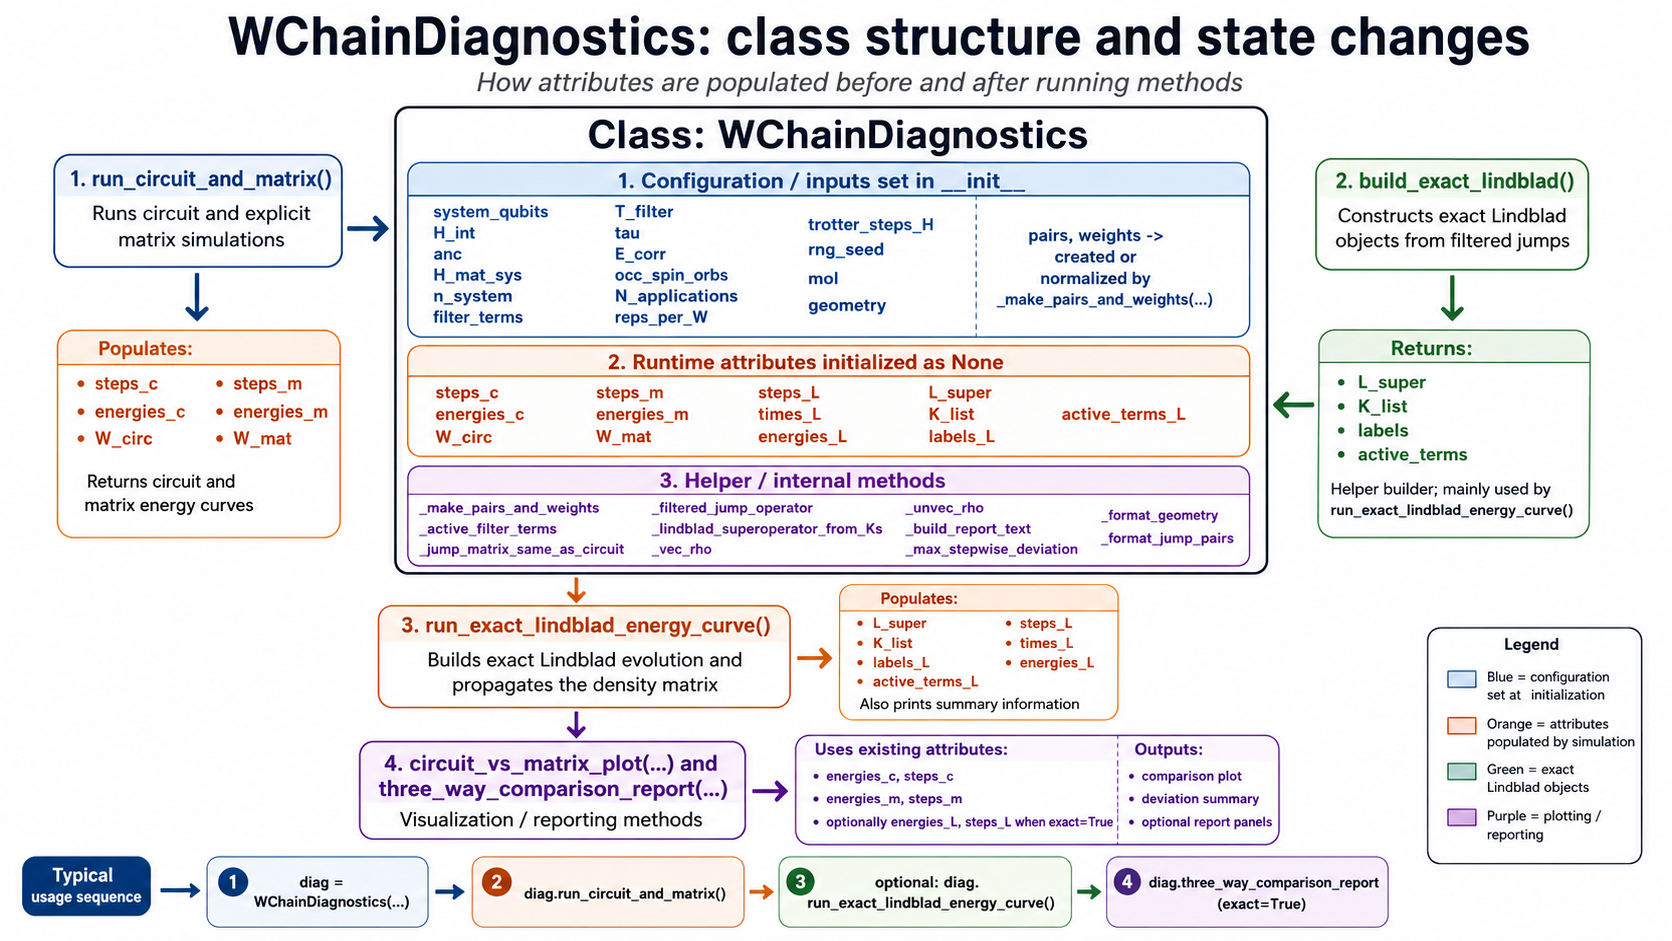

## Parameter Sweep

In [16]:
import itertools
import math
import contextlib
import io


def parameter_sweep_subfigures(
    self,
    diff_occ=False,
    diff_order=False,
    diff_reps=False,
    occ_spin_orbs_list=None,
    trotter_orders=None,
    reps_per_W_list=None,
    max_panels=6,
    exact=False,
    rebuild_pairs_from_occ=True,
    quiet=True,
    figsize=(15, 9),
):
    """
    Make one figure with up to 6 subfigures.

    Set one or more of:
        diff_occ=True
        diff_order=True
        diff_reps=True

    If more than one flag is True, the code uses the Cartesian product.
    Example:
        2 occ choices x 3 reps choices = 6 subfigures.

    exact:
        False: do NOT run exact Lindblad simulation.
        True : run exact Lindblad simulation and include it in the plot.
    """

    if diff_occ and occ_spin_orbs_list is None:
        raise ValueError("You set diff_occ=True, so provide occ_spin_orbs_list.")
    if diff_order and trotter_orders is None:
        raise ValueError("You set diff_order=True, so provide trotter_orders.")
    if diff_reps and reps_per_W_list is None:
        raise ValueError("You set diff_reps=True, so provide reps_per_W_list.")

    occ_values = occ_spin_orbs_list if diff_occ else [self.occ_spin_orbs]
    order_values = trotter_orders if diff_order else [self.trotter_steps_H]
    reps_values = reps_per_W_list if diff_reps else [self.reps_per_W]

    combos = list(itertools.product(occ_values, order_values, reps_values))

    if len(combos) > max_panels:
        raise ValueError(
            f"You requested {len(combos)} subfigures, but max_panels={max_panels}. "
            "Reduce the input lists or increase max_panels."
        )

    n_panels = len(combos)
    ncols = 3 if n_panels > 1 else 1
    nrows = math.ceil(n_panels / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes_flat = axes.ravel()

    all_results = []

    for idx, (occ_now, order_now, reps_now) in enumerate(combos):
        ax = axes_flat[idx]

        pairs_now = None if (diff_occ and rebuild_pairs_from_occ) else self.pairs
        weights_now = None if (diff_occ and rebuild_pairs_from_occ) else self.weights

        diag_now = WChainDiagnostics(
            system_qubits=self.system_qubits,
            H_int=self.H_int,
            anc=self.anc,
            H_mat_sys=self.H_mat_sys,
            n_system=self.n_system,
            filter_terms=self.filter_terms,
            T_filter=self.T_filter,
            tau=self.tau,
            E_corr=self.E_corr,
            occ_spin_orbs=list(occ_now),
            N_applications=self.N_applications,
            reps_per_W=reps_now,
            trotter_steps_H=order_now,
            rng_seed=self.rng_seed,
            pairs=pairs_now,
            weights=weights_now,
            mol=self.mol,
            geometry=self.geometry,
        )

        if quiet:
            with contextlib.redirect_stdout(io.StringIO()):
                diag_now.run_circuit_and_matrix()
        else:
            diag_now.run_circuit_and_matrix()

        ax.plot(
            diag_now.steps_c,
            diag_now.energies_c,
            lw=1.7,
            ms=3,
            label="Circuit W",
            color="steelblue",
        )

        ax.plot(
            diag_now.steps_m,
            diag_now.energies_m,
            lw=1.7,
            ms=3,
            label="Matrix W",
            color="tomato",
        )

        if exact:
            if quiet:
                with contextlib.redirect_stdout(io.StringIO()):
                    diag_now.run_exact_lindblad_energy_curve()
            else:
                diag_now.run_exact_lindblad_energy_curve()

            ax.plot(
                diag_now.steps_L,
                diag_now.energies_L,
                "k-",
                lw=2.0,
                label=r"Exact $e^{t\mathcal{L}_{\rm avg}}$",
            )

        ax.axhline(
            self.E_corr,
            color="gray",
            ls=":",
            lw=1.2,
            label=f"GS = {self.E_corr:.6f}",
        )

        ax.axhline(
            self.E_corr + self.tau**2,
            color="red",
            lw=1.2,
            label=r"GS $+\tau^2$",
        )

        caption = f"occ={list(occ_now)}, order={order_now}, reps={reps_now}"
        ax.set_title(caption, fontsize=10)
        ax.set_xlabel("W applications", fontsize=9)
        ax.set_ylabel(r"$\langle H\rangle$", fontsize=9)
        ax.grid(True, alpha=0.35)
        ax.legend(fontsize=7)

        result_now = {
            "occ_spin_orbs": list(occ_now),
            "trotter_steps_H": order_now,
            "reps_per_W": reps_now,
            "steps_c": diag_now.steps_c,
            "energies_c": diag_now.energies_c,
            "steps_m": diag_now.steps_m,
            "energies_m": diag_now.energies_m,
            "diag": diag_now,
        }

        if exact:
            result_now.update(
                {
                    "steps_L": diag_now.steps_L,
                    "energies_L": diag_now.energies_L,
                    "L_super": diag_now.L_super,
                    "K_list": diag_now.K_list,
                }
            )

        all_results.append(result_now)

    for j in range(n_panels, len(axes_flat)):
        axes_flat[j].axis("off")

    title_bits = []
    if diff_occ:
        title_bits.append("occupied spin orbitals")
    if diff_order:
        title_bits.append("Trotter order")
    if diff_reps:
        title_bits.append("Fourier cutoff reps_per_W")

    title_text = (
        "Parameter sweep: " + ", ".join(title_bits)
        if title_bits
        else "Single parameter setting"
    )

    if exact:
        title_text += " with exact Lindblad"
    else:
        title_text += " without exact Lindblad"

    fig.suptitle(title_text, fontsize=14)
    plt.tight_layout()
    plt.show()

    return all_results


# Attach this method to the existing class.
WChainDiagnostics.parameter_sweep_subfigures = parameter_sweep_subfigures

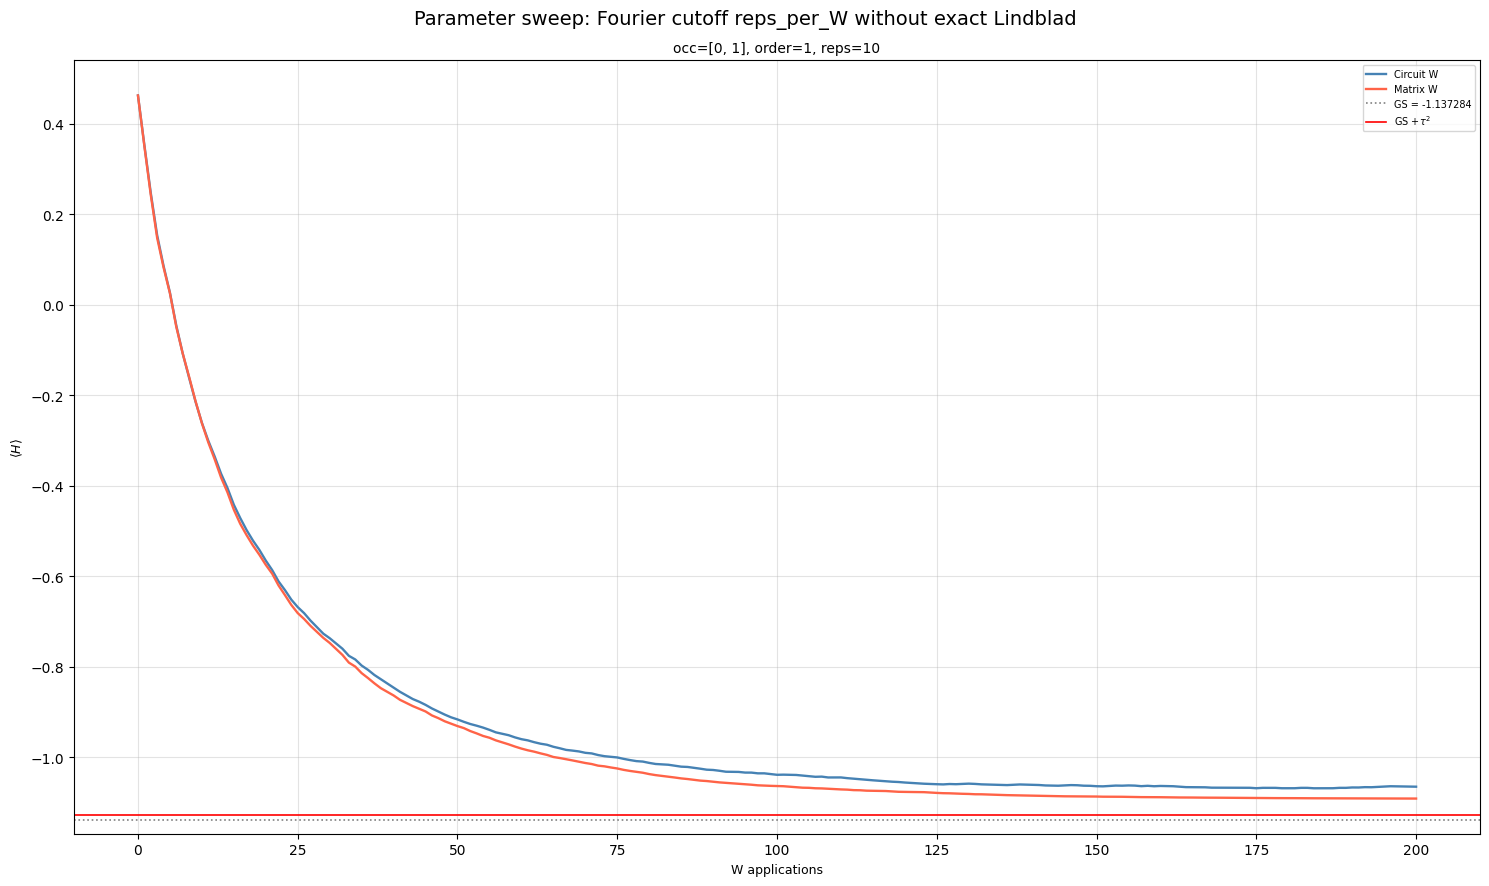

In [ ]:
'''results_reps = diag.parameter_sweep_subfigures(
    diff_occ=False,
    diff_order=False,
    diff_reps=True,
    reps_per_W_list=[10],
    exact=False
)'''

In [18]:
'''results_occ_reps = diag.parameter_sweep_subfigures(
    diff_occ=True,
    diff_order=False,
    diff_reps=False,
    occ_spin_orbs_list=[
        [2, 3, 4, 5],
        [0, 1],
        [0, 1, 2],
        [0, 1, 2, 3],
        [0, 1, 2, 3, 4],
        [1, 2, 3, 4],
    ],
    reps_per_W_list=5,
)'''

'results_occ_reps = diag.parameter_sweep_subfigures(\n    diff_occ=True,\n    diff_order=False,\n    diff_reps=False,\n    occ_spin_orbs_list=[\n        [2, 3, 4, 5],\n        [0, 1],\n        [0, 1, 2],\n        [0, 1, 2, 3],\n        [0, 1, 2, 3, 4],\n        [1, 2, 3, 4],\n    ],\n    reps_per_W_list=5,\n)'

##                                                                      END

In [19]:

import pickle
import cirq

from pyLIQTR.utils.resource_analysis import estimate_resources

# 1. Load saved circuit
with open("W_circ_last.pkl", "rb") as f:
    W_circ = pickle.load(f)

# 2. Check it is a Cirq circuit
print(type(W_circ))
#print(W_circ)

# 4. Resource estimate
resources = estimate_resources(
    W_circ,
    rotation_gate_precision=1e-10,
)

print(500*resources["T"])

<class 'cirq.circuits.circuit.Circuit'>
273086000


In [20]:
def one_step_eigenstate_energy_drifts(diag, basic=None, W_cache=None, atol=1e-12):
    """
    Apply one averaged W-channel step to every exact eigenstate of H.

    Direct diagnostic:
        delta_E_j = Tr(H E_W(|Ej><Ej|)) - Ej

    Cooling expectation:
        delta_E_j < 0 for most excited states,
        while j=0 should remain almost stable.
    """
    H = np.asarray(diag.H_mat_sys, dtype=complex)
    H = 0.5 * (H + H.conj().T)

    if basic is None:
        evals, evecs = np.linalg.eigh(H)
    else:
        evals = basic["evals"]
        evecs = basic["evecs"]

    if W_cache is None:
        W_cache = build_W_cache_for_all_pairs(diag)

    rows = []

    for j, Ej in enumerate(evals):
        psi_j = evecs[:, j]
        rho_j = np.outer(psi_j, psi_j.conj())

        rho_after = apply_averaged_W_channel_from_cache(diag, rho_j, W_cache)

        E_after = float(np.real(np.trace(rho_after @ H)))
        delta_E = E_after - float(Ej)

        # Population transferred into the true ground state after one step
        psi0 = evecs[:, 0]
        ground_pop_after = float(np.real(psi0.conj().T @ rho_after @ psi0))

        if j == 0:
            label = "ground"
        elif delta_E < -atol:
            label = "downhill"
        elif delta_E > atol:
            label = "uphill"
        else:
            label = "flat"

        rows.append({
            "j": j,
            "E_j": float(Ej),
            "E_after": E_after,
            "delta_E": delta_E,
            "ground_pop_after": ground_pop_after,
            "label": label,
        })

    # Print compact report
    n_excited = len(rows) - 1
    n_downhill = sum(r["label"] == "downhill" for r in rows[1:])
    n_uphill = sum(r["label"] == "uphill" for r in rows[1:])
    n_flat = sum(r["label"] == "flat" for r in rows[1:])

    print("====================================")
    print(" One-Step Eigenstate Energy Drifts")
    print("====================================")
    print(f"Number of eigenstates        = {len(rows)}")
    print(f"Excited states tested        = {n_excited}")
    print(f"Downhill excited states      = {n_downhill}")
    print(f"Uphill excited states        = {n_uphill}")
    print(f"Flat excited states          = {n_flat}")
    print()
    print("j    E_j                  E_after              delta_E              label")
    print("-" * 85)

    for r in rows:
        print(
            f"{r['j']:2d}   "
            f"{r['E_j']: .12e}   "
            f"{r['E_after']: .12e}   "
            f"{r['delta_E']: .12e}   "
            f"{r['label']}"
        )

    return rows

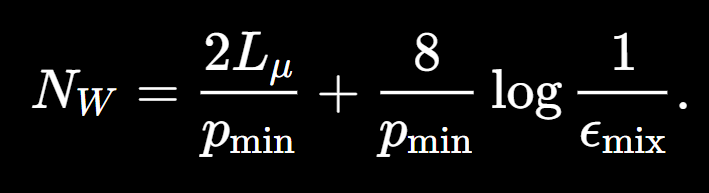

input: <code>p_min</code>, Hamiltonian norm, gap, number of orbitals fixed in the active space CAS method earlier in the code. Setting <code>p_min~0.2</code> matches with the result from <code>tau_s=0.1</code>

From above, collect 1. Fixed orbital number 2. set number of applications <code>N_application</code> according to the formula (define <code>get_W_rep()</code>) and store the bound and return

In [21]:
import numpy as np

def get_W_rep(
    diag,
    epsilon_E,
    p_min,
    H_norm=None,
    gap=None,
    N_o=None,
    L_mu=None,
    set_diag=True,
):
    """
    Compute and optionally set diag.N_applications using the one-Hamiltonian
    local cooling/hitting-time bound.

    This is NOT the full reaction-path gate complexity.
    This estimates the number of W applications for one fixed Hamiltonian.

    Formula:
        N_W = ceil( 2 L_mu / p_min + 8 log(1/epsilon_mix) / p_min )

    Here:
        L_mu is the initial energy-layer radius.
        If L_mu is not supplied, we use the theorem-level assumption L_mu = O(N_o)
        and set L_mu = N_o.

    The Hamiltonian norm and gap are stored for reference, but they do not
    directly determine N_W in this local mixing formula.
    """

    H = np.asarray(diag.H_mat_sys, dtype=complex)
    H = 0.5 * (H + H.conj().T)

    evals = np.linalg.eigvalsh(H)
    E0 = float(evals[0])
    E1 = float(evals[1])
    Emax = float(evals[-1])

    if H_norm is None:
        H_norm = float(np.linalg.norm(H, ord=2))

    if gap is None:
        gap = float(E1 - E0)

    if N_o is None:
        # In your uploaded builder:
        # n_system = 2 * n_active_orbitals
        # Therefore active spatial orbitals = n_system / 2
        N_o = int(diag.n_system // 2)

    if L_mu is None:
        # Theory assumption: warm-start layer radius scales as O(N_o).
        # For this first implementation, take the constant as 1.
        L_mu = int(N_o)

    if p_min <= 0:
        raise ValueError("p_min must be positive.")

    if epsilon_E <= 0:
        raise ValueError("epsilon_E must be positive.")

    spectral_width = Emax - E0

    # Convert energy target into a failure-probability target.
    # If remaining non-ground population is <= epsilon_mix,
    # then energy error is bounded by epsilon_mix * (Emax - E0).
    epsilon_mix = epsilon_E / spectral_width

    if epsilon_mix <= 0 or epsilon_mix >= 1:
        raise ValueError(
            "epsilon_mix must lie in (0,1). Check epsilon_E and spectral width."
        )

    N_W_bound = int(np.ceil(
        (2.0 * L_mu / p_min)
        +
        (8.0 / p_min) * np.log(1.0 / epsilon_mix)
    ))

    bound_info = {
        "N_W_bound": N_W_bound,
        "epsilon_E": float(epsilon_E),
        "epsilon_mix": float(epsilon_mix),
        "p_min": float(p_min),
        "L_mu": int(L_mu),
        "N_o_active_spatial_orbitals": int(N_o),
        "n_system_spin_orbitals_or_qubits": int(diag.n_system),
        "H_norm": float(H_norm),
        "gap": float(gap),
        "E0": float(E0),
        "Emax": float(Emax),
        "spectral_width": float(spectral_width),
    }

    if set_diag:
        diag.N_applications = N_W_bound
        diag.W_bound_info = bound_info

    return N_W_bound, bound_info

In [22]:
def filter_leakage_diagnostics(
    diag,
    candidate_reps=None,
    omega_tol=1e-12,
    print_summary=True,
    make_plots=True,
):
    """
    Compute filter leakage diagnostics for a WChainDiagnostics object.

    By default, this reproduces the same outputs as the original notebook cell:
      1. returns filter_leakage_info
      2. prints the leakage summary
      3. shows the two diagnostic plots

    Parameters
    ----------
    diag:
        A WChainDiagnostics object.

    candidate_reps:
        List of Fourier cutoffs to test. These are cutoffs on |k| <= reps.
        If None, uses the original default list.

    omega_tol:
        Numerical tolerance used to classify Bohr frequencies as heating/cooling.

    print_summary:
        If True, print the same text summary as the original cell.

    make_plots:
        If True, show the same two plots as the original cell.

    Returns
    -------
    filter_leakage_info : dict
        Dictionary containing current leakage data, sweep results, eigenvalues,
        omega matrix, and current filter response.
    """

    import numpy as np
    import matplotlib.pyplot as plt

    # ============================================================
    # USER SETTINGS
    # ============================================================

    if candidate_reps is None:
        candidate_reps = [1, 3, 5, 7, 9, 15, 25, 50, 100, 150, 250, 500]

    # ============================================================
    # BASIC SPECTRAL DATA
    # ============================================================

    H = np.asarray(diag.H_mat_sys, dtype=complex)
    H = 0.5 * (H + H.conj().T)

    evals, evecs = np.linalg.eigh(H)
    psi0 = evecs[:, 0]
    E0 = float(evals[0])

    omega_mat = evals[:, None] - evals[None, :]   # omega_{m,n} = E_m - E_n

    heating_mask = omega_mat > omega_tol
    cooling_mask = omega_mat < -omega_tol

    all_filter_terms = list(diag.filter_terms)
    available_kmax = max(abs(int(k)) for k, _ in all_filter_terms)

    reps_list = [r for r in candidate_reps if r <= available_kmax]
    if available_kmax not in reps_list:
        reps_list.append(available_kmax)

    weights = np.asarray(diag.weights, dtype=float)
    weights = weights / weights.sum()

    # ============================================================
    # SWEEP k-CUTOFF AND COMPUTE LEAKAGE
    # ============================================================

    sweep_rows = []

    for reps in reps_list:
        active_terms = [(k, ck) for (k, ck) in all_filter_terms if abs(k) <= reps]

        # ------------------------------------------------------------
        # 1. Pure filter response F_K(omega)
        # ------------------------------------------------------------
        F = np.zeros_like(omega_mat, dtype=complex)

        for k, ck in active_terms:
            F += ck * np.exp(1j * omega_mat * k * diag.T_filter)

        F_abs2 = np.abs(F) ** 2

        max_heating_response = float(np.max(F_abs2[heating_mask]))
        mean_heating_response = float(np.mean(F_abs2[heating_mask]))

        max_cooling_response = float(np.max(F_abs2[cooling_mask]))
        mean_cooling_response = float(np.mean(F_abs2[cooling_mask]))

        # Ground-state heating frequencies: source = ground state n=0, target m>0
        ground_heating_response = F_abs2[1:, 0]
        max_ground_heating_response = float(np.max(ground_heating_response))
        mean_ground_heating_response = float(np.mean(ground_heating_response))

        # ------------------------------------------------------------
        # 2. Actual operator leakage sum_a w_a ||K_a |E0>||^2
        # ------------------------------------------------------------
        per_jump_leakage = []
        per_jump_labels = []

        for weight, pair in zip(weights, diag.pairs):
            if len(pair) == 2:
                i, j = pair
                jump_type = "Ax"
            else:
                i, j, jump_type = pair

            A_mat = diag._jump_matrix_same_as_circuit(i, j, jump_type)
            K_mat = diag._filtered_jump_operator(A_mat, active_terms, evals, evecs)

            leak = float(np.linalg.norm(K_mat @ psi0) ** 2)

            per_jump_leakage.append(leak)
            per_jump_labels.append((i, j, jump_type))

        per_jump_leakage = np.array(per_jump_leakage, dtype=float)

        weighted_ground_leakage_rate = float(np.sum(weights * per_jump_leakage))

        # For a small Lindblad step, the per-step leakage scale is approximately tau * rate.
        estimated_per_step_ground_leakage = float(
            diag.tau * weighted_ground_leakage_rate
        )

        sweep_rows.append({
            "reps": int(reps),
            "num_active_terms": int(len(active_terms)),
            "active_k_values": [int(k) for k, _ in active_terms],
            "weighted_ground_leakage_rate": weighted_ground_leakage_rate,
            "estimated_per_step_ground_leakage": estimated_per_step_ground_leakage,
            "per_jump_leakage": per_jump_leakage,
            "per_jump_labels": per_jump_labels,
            "max_heating_filter_response_sq": max_heating_response,
            "mean_heating_filter_response_sq": mean_heating_response,
            "max_cooling_filter_response_sq": max_cooling_response,
            "mean_cooling_filter_response_sq": mean_cooling_response,
            "max_ground_heating_filter_response_sq": max_ground_heating_response,
            "mean_ground_heating_filter_response_sq": mean_ground_heating_response,
        })

    # ============================================================
    # CURRENT ACTIVE SET ACCORDING TO diag.reps_per_W
    # ============================================================

    current_reps = diag.reps_per_W
    if current_reps is None:
        current_active_terms = list(all_filter_terms)
    else:
        current_active_terms = [
            (k, ck) for (k, ck) in all_filter_terms if abs(k) <= current_reps
        ]

    F_current = np.zeros_like(omega_mat, dtype=complex)
    for k, ck in current_active_terms:
        F_current += ck * np.exp(1j * omega_mat * k * diag.T_filter)

    F_current_abs2 = np.abs(F_current) ** 2

    current_per_jump_leakage = []
    current_per_jump_labels = []

    for weight, pair in zip(weights, diag.pairs):
        if len(pair) == 2:
            i, j = pair
            jump_type = "Ax"
        else:
            i, j, jump_type = pair

        A_mat = diag._jump_matrix_same_as_circuit(i, j, jump_type)
        K_mat = diag._filtered_jump_operator(A_mat, current_active_terms, evals, evecs)

        leak = float(np.linalg.norm(K_mat @ psi0) ** 2)

        current_per_jump_leakage.append(leak)
        current_per_jump_labels.append((i, j, jump_type))

    current_per_jump_leakage = np.array(current_per_jump_leakage, dtype=float)

    current_weighted_ground_leakage_rate = float(
        np.sum(weights * current_per_jump_leakage)
    )
    current_estimated_per_step_ground_leakage = float(
        diag.tau * current_weighted_ground_leakage_rate
    )

    # ============================================================
    # STORE RESULTS IN VARIABLE
    # ============================================================

    filter_leakage_info = {
        "current_reps_per_W": current_reps,
        "current_num_active_terms": len(current_active_terms),
        "current_active_k_values": [int(k) for k, _ in current_active_terms],
        "current_weighted_ground_leakage_rate": current_weighted_ground_leakage_rate,
        "current_estimated_per_step_ground_leakage": current_estimated_per_step_ground_leakage,
        "current_per_jump_leakage": current_per_jump_leakage,
        "current_per_jump_labels": current_per_jump_labels,
        "sweep_rows": sweep_rows,
        "evals": evals,
        "omega_mat": omega_mat,
        "F_current_abs2": F_current_abs2,
    }

    # ============================================================
    # PRINT SUMMARY
    # ============================================================

    if print_summary:
        print("==============================================")
        print(" Filter leakage diagnostics")
        print("==============================================")
        print(f"diag.reps_per_W                         = {current_reps}")
        print(f"number of currently active k terms       = {len(current_active_terms)}")
        print(f"currently active k values                = {[int(k) for k, _ in current_active_terms]}")
        print()
        print(f"tau                                      = {diag.tau:.12e}")
        print(f"weighted ground leakage rate             = {current_weighted_ground_leakage_rate:.12e}")
        print(f"estimated per-step ground leakage tau*rate = {current_estimated_per_step_ground_leakage:.12e}")
        print()
        print("Per-jump ground leakage ||K_a |E0>||^2:")
        for label, leak in zip(current_per_jump_labels, current_per_jump_leakage):
            print(f"  {label}: {leak:.12e}")

        print()
        print("Sweep over k cutoff:")
        print("reps   #terms   weighted_ground_leakage_rate   tau*rate      max_heating_filter_response")
        print("-" * 95)
        for row in sweep_rows:
            print(
                f"{row['reps']:4d}   "
                f"{row['num_active_terms']:6d}   "
                f"{row['weighted_ground_leakage_rate']:.12e}   "
                f"{row['estimated_per_step_ground_leakage']:.12e}   "
                f"{row['max_heating_filter_response_sq']:.12e}"
            )

    # ============================================================
    # PLOTS
    # ============================================================

    if make_plots:
        # ------------------------------------------------------------
        # PLOT 1: ACTUAL GROUND-STATE LEAKAGE VS NUMBER OF k TERMS
        # ------------------------------------------------------------

        x_terms = np.array([row["num_active_terms"] for row in sweep_rows])
        y_ground_leak = np.array([row["weighted_ground_leakage_rate"] for row in sweep_rows])
        y_step_leak = np.array([row["estimated_per_step_ground_leakage"] for row in sweep_rows])

        plt.figure(figsize=(8, 5))
        plt.semilogy(
            x_terms,
            np.maximum(y_ground_leak, 1e-18),
            marker="o",
            color="tab:blue",
            linestyle="-",
            linewidth=2.0,
            label=r"$\sum_a w_a\|K_a|E_0\rangle\|^2$"
        )
        plt.semilogy(
            x_terms,
            np.maximum(y_step_leak, 1e-18),
            marker="s",
            color="tab:orange",
            linestyle="--",
            linewidth=2.0,
            label=r"$\tau_s\sum_a w_a\|K_a|E_0\rangle\|^2$"
        )
        plt.xlabel("Number of active Fourier k terms")
        plt.ylabel("Ground-state leakage")
        plt.title("Ground-state leakage versus number of k modes")
        plt.grid(True, which="both", alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # ------------------------------------------------------------
        # PLOT 2: CURRENT FILTER RESPONSE AT BOHR FREQUENCIES
        # ------------------------------------------------------------

        omega_flat = omega_mat.reshape(-1)
        F_flat = F_current_abs2.reshape(-1)

        heating_flat = omega_flat > omega_tol
        cooling_flat = omega_flat < -omega_tol

        plt.figure(figsize=(8, 5))
        plt.scatter(
            omega_flat[cooling_flat],
            F_flat[cooling_flat],
            color="tab:green",
            marker="o",
            label="cooling frequencies, omega < 0"
        )
        plt.scatter(
            omega_flat[heating_flat],
            F_flat[heating_flat],
            color="tab:red",
            marker="x",
            label="heating frequencies, omega > 0"
        )
        plt.yscale("log")
        plt.xlabel(r"Bohr frequency $\omega=E_m-E_n$")
        plt.ylabel(r"$|F_K(\omega)|^2$")
        plt.title("Current discrete filter response at Bohr frequencies")
        plt.grid(True, which="both", alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return filter_leakage_info